## Impact of Assimilating GPS Precipitable Water Vapor on Simulations of  two North American Monsoon Convective Events using Observing System Simulation Experiments
##### Samkeyat Shohan, Steven E. Koch, Christopher L. Castro, Avelino F. Arellano, Junkyung Kay, Christoforus Bayu Risanto, Tammy M. Weckwerth, James O. Pinto, David K. Adams

The OSSE approach using GPS-equivalent synthetic PWV observations involves three key steps. First, we generated a NR by objectively choosing the best performing member among a 40-member ensemble forecasting system using randomly perturbed initial conditions (Anderson 2001; Whitaker and Hamill 2002) that produces the most representative state of the atmosphere. Second, we extracted synthetic PWV observations by applying bilinear interpolation (Jones 1999) from the NR using the superobbed stations from 2021 campaign in Arizona and uniform arrays (50, 100 and 200km) and then added random noise based on observation error specification. Third, we employed the WRF/DART system to assimilate the synthetic PWV observations extracted from the NR over a 6-hour window into a coarser model and subsequently executed an 18-hour “free forecast”. We will describe the codes in following steps: 
1. Nature Run (NR) Selection
2. Elevation-dependent Bias Correction
3. DART Readable Synthetic Observations Generation
4. Setups of Different Observation Stations
5. Synoptic Overview of the two North American Monsson (NAM) Cases
6. Metrics and Evaluation Tools

### 1. Nature Run (NR) Selection
##### Plot Accumulated Precipitation for all 40 members to select three best NR ensemble members

Processing: mem02_wrfout_d02_2021-08-16_12:00:00
Processing: mem03_wrfout_d02_2021-08-16_12:00:00
Processing: mem31_wrfout_d02_2021-08-16_12:00:00


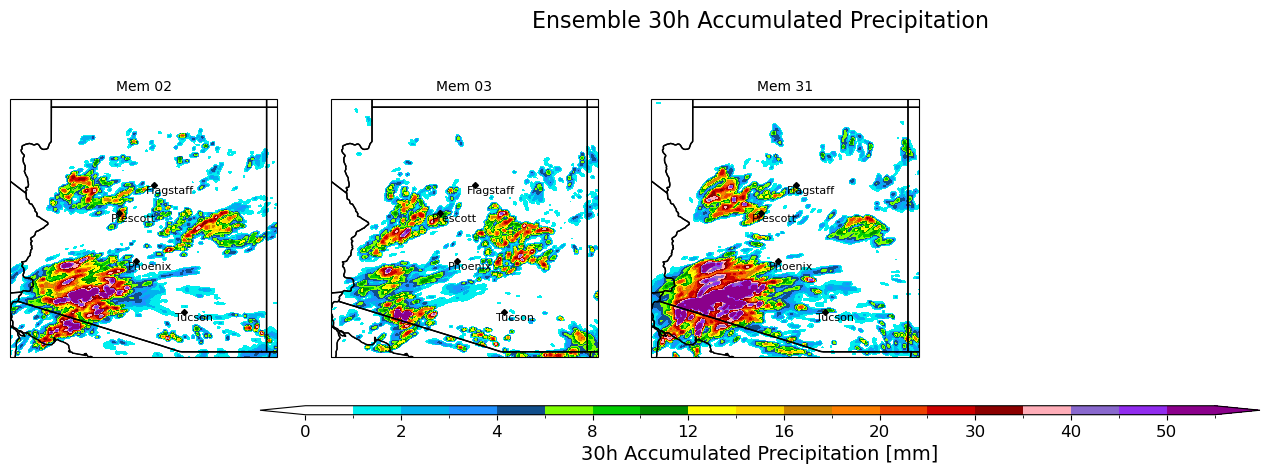

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import cartopy.crs as ccrs
import cartopy.feature as cf
from netCDF4 import Dataset
import glob
import os

class PrecipitationPlotter:
    def __init__(self, file_pattern='mem*', output_dir='.', extent=None):
        self.file_pattern = file_pattern
        self.output_dir = output_dir
        self.filelist = sorted(glob.glob(self.file_pattern))
        self.extent = extent or [-115, -108.8, 31.2, 37.2]
        self.cities = {
            'Phoenix': (-112.07, 33.44),
            'Tucson': (-110.97, 32.25),
            'Prescott': (-112.46, 34.54),
            'Flagstaff': (-111.65, 35.19),
        }
        self.var_levels = [0., 1, 2, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60]
        self.cmap = ListedColormap([
            '#ffffff', '#00eeee', '#00b2ee', '#1e90ff', '#104e8b',
            '#7fff00', '#00cd00', '#008b00', '#ffff00', '#ffd700',
            '#cd8500', '#ff7f00', '#ee4000', '#cd0000', '#8b0000',
            '#ffaeb9', '#8968cd', '#912cee', '#8b008b'
        ], name='precip_hr')
        self.norm = BoundaryNorm(self.var_levels, self.cmap.N)

        # Set global plot styles
        rcParams.update({'font.size': 16})
        rcParams['xtick.labelsize'] = 12
        rcParams['ytick.labelsize'] = 12

    def load_data(self, filepath):
        with Dataset(filepath, 'r') as nc:
            lat = nc.variables['XLAT'][0, :, 0]
            lon = nc.variables['XLONG'][0, 0, :]
            var = nc.variables['RAINNC'][0, :, :]
            var[var == 0] = np.nan
        return lat, lon, var

    def plot_single_member(self, filename):
        lat, lon, var = self.load_data(filename)
        member_id = filename[3:5]

        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
        ax.set_extent(self.extent)

        # Add base map features
        ax.add_feature(cf.BORDERS, linewidth=0.5)
        ax.add_feature(cf.STATES, edgecolor="k")
        ax.add_feature(cf.COASTLINE, linewidth=0.8)

        # Plot cities
        for city, coords in self.cities.items():
            ax.plot(*coords, 'kD', transform=ccrs.PlateCarree())
            ax.text(coords[0] - 0.2, coords[1] - 0.2, city, fontsize=14, transform=ccrs.PlateCarree())

        # Add gridlines
        gl = ax.gridlines(draw_labels=False, linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.bottom_labels = True
        gl.left_labels = True

        # Title
        ax.set_title(f'NR ENS: {member_id} Time: 2021081506-2021081612 (30H)')

        # Plot variable
        pc = ax.contourf(lon, lat, var, levels=self.var_levels, cmap=self.cmap, norm=self.norm, extend='both')

        # Colorbar
        divider = make_axes_locatable(ax)
        cbar = fig.colorbar(pc, orientation='horizontal', fraction=0.045, pad=0.1, extend='both')
        cbar.set_label('30h Accumulated Precipitation [mm]', fontsize=16)

        # Save output
        output_path = os.path.join(self.output_dir, f'ENS_mem_{member_id}_accum_precip.jpg')
        fig.savefig(output_path, dpi=360, bbox_inches='tight')
        plt.show()
        plt.close(fig)

    def run_all_subplots(self, ncols=5):
        num_files = len(self.filelist)
        nrows = int(np.ceil(num_files / ncols))
        
        fig, axes = plt.subplots(
            nrows=nrows, ncols=ncols, figsize=(4*ncols, 4.5*nrows),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )
        axes = axes.flatten()
        
        for idx, fl in enumerate(self.filelist):
            print(f"Processing: {fl}")
            lat, lon, var = self.load_data(fl)
            member_id = fl[3:5]
            ax = axes[idx]
            ax.set_extent(self.extent)
    
            # Base map features
            ax.add_feature(cf.BORDERS, linewidth=0.5)
            ax.add_feature(cf.STATES, edgecolor="k")
            ax.add_feature(cf.COASTLINE, linewidth=0.8)
    
            # Cities
            for city, coords in self.cities.items():
                ax.plot(*coords, 'kD', transform=ccrs.PlateCarree(), markersize=3)
                ax.text(coords[0] - 0.2, coords[1] - 0.2, city, fontsize=8, transform=ccrs.PlateCarree())
    
            # Title
            ax.set_title(f'Mem {member_id}', fontsize=10)
    
            # Contourf
            pc = ax.contourf(lon, lat, var, levels=self.var_levels, cmap=self.cmap, norm=self.norm, extend='both')
    
        # Hide extra axes if any
        for j in range(idx + 1, len(axes)):
            fig.delaxes(axes[j])
    
        # Add a shared colorbar
        cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
        cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', extend='both')
        cbar.set_label('30h Accumulated Precipitation [mm]', fontsize=14)
    
        # Save and show
        fig.suptitle('Ensemble 30h Accumulated Precipitation', fontsize=16)
        output_path = os.path.join(self.output_dir, 'ENS_all_members_accum_precip.jpg')
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.show()

# Example usage
if __name__ == "__main__":
    plotter = PrecipitationPlotter()
    plotter.run_all_subplots()


##### Plot Similar Observational Data for Verification Purposes. We have used MRMS accumulated Precipitation.

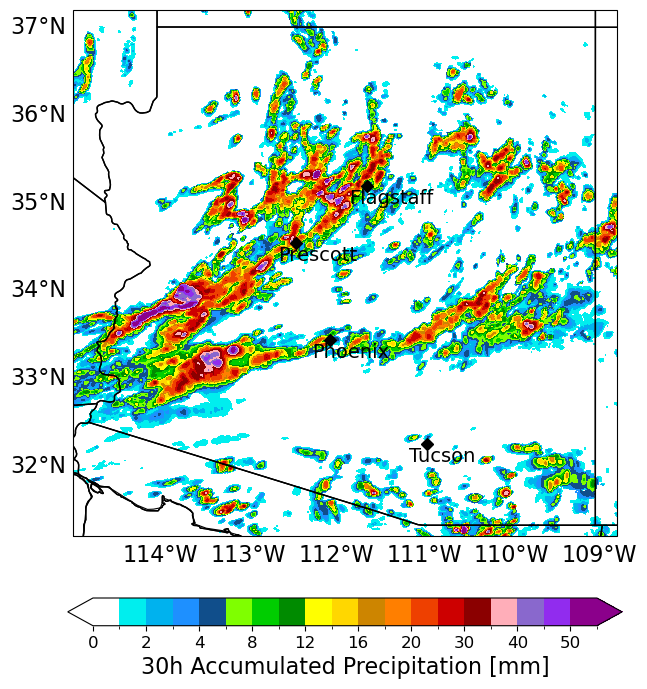

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import matplotlib as mplt
import cartopy.crs as ccrs
import cartopy.feature as cf
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors

class PrecipitationPlotter:
    def __init__(self, nc_file, output_file, bbox=None):
        self.nc_file = nc_file
        self.output_file = output_file
        self.bbox = bbox or [-115, -108.8, 31.2, 37.2]
        self.cities = {
            'Phoenix': (-112.07, 33.44),
            'Tucson': (-110.97, 32.25),
            'Prescott': (-112.46, 34.54),
            'Flagstaff': (-111.65, 35.19)
        }
        self._load_data()
        self._set_colormap()

    def _load_data(self):
        nc = Dataset(self.nc_file, 'r')
        self.lat = nc.variables['lat_0'][:]
        self.lon = nc.variables['lon_0'][:]
        self.precip = nc.variables['PRECIP'][:, :]
        self.precip[self.precip == 0] = np.nan

    def _set_colormap(self):
        pcp_colors = ['#ffffff', '#00eeee', '#00b2ee', '#1e90ff', '#104e8b',
                      '#7fff00', '#00cd00', '#008b00', '#ffff00', '#ffd700',
                      '#cd8500', '#ff7f00', '#ee4000', '#cd0000', '#8b0000',
                      '#ffaeb9', '#8968cd', '#912cee', '#8b008b']
        self.precip_cmap = matplotlib.colors.ListedColormap(pcp_colors, 'precip_hr')
        self.precip_levels = [0., 1, 2, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20, 25, 30, 35, 40, 45, 50, 60]
        self.norm = matplotlib.colors.BoundaryNorm(self.precip_levels, self.precip_cmap.N)

    def plot(self):
        fig = plt.figure(figsize=(10, 8))
        ax = plt.subplot(111, projection=ccrs.PlateCarree())
        ax.set_extent(self.bbox)

        mplt.rc('xtick', labelsize=12)
        mplt.rc('ytick', labelsize=12)
        plt.rcParams.update({'font.size': 16})

        # Map features
        ax.add_feature(cf.BORDERS, linewidth=0.5, edgecolor="k")
        ax.add_feature(cf.STATES, edgecolor="k")
        ax.add_feature(cf.COASTLINE, edgecolor="k")
        ax.coastlines('50m', linewidth=0.8)

        # Gridlines
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                          linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.bottom_labels = True
        gl.left_labels = True
        gl.right_labels = False
        gl.xlines = False
        gl.ylines = False

        # Cities
        for city, (lon, lat) in self.cities.items():
            ax.plot(lon, lat, 'kD', transform=ccrs.PlateCarree())
            ax.text(lon - 0.2, lat - 0.2, city, fontsize=14, transform=ccrs.PlateCarree())

        # Precipitation plot
        pc = ax.contourf(self.lon, self.lat, self.precip, levels=self.precip_levels,
                         cmap=self.precip_cmap, norm=self.norm, extend='both')

        # Colorbar
        divider = make_axes_locatable(ax)
        cbar = fig.colorbar(pc, orientation="horizontal",fraction=0.045, pad=0.1, extend='both')
        cbar.set_label('30h Accumulated Precipitation [mm]', fontsize=16)

        # Save figure
        fig.savefig(self.output_file, dpi=360, bbox_inches='tight')
        plt.show()

# Example usage
if __name__ == "__main__":
    plotter = PrecipitationPlotter(
        nc_file='MRMS_accumulated_precip_1506_1612.nc',
        output_file='MRMS_accup_precip_1506_1612.png'
    )
    plotter.plot()


##### Now that we have three best members out of 40 ensembles, we can compare precipitable water vapor (PWV) extracted from these three candidates with the real pwv observations collected during the 2021 GPS-MET field campaign to select the best candidates for the NR. The steps are as follows:

##### 1. Calculate spatial PWV files from hourly WRF outputs for each of the selected NR candidates
$$
\text{PWV}_{i,j} = \frac{1}{\rho_w g} \sum_{k=1}^{n_k - 1} \frac{1}{2} \left( \text{MR}_k + \text{MR}_{k+1} \right) \left( p_k - p_{k+1} \right)
$$
$ρw$ is liquid water density, $𝑔$ is the acceleration due to gravity, $MR$ is the water vapor mixing ratio where $MR  = QVAPOR/(1 - QVAPOR)$ and $QVAPOR$ is the specific humidity. $k=1$ denotes the lowest model level, $n_k$ indicates total number of model levels, and $p$ represents the model-equivalent pressure interpolated from domain d02

In [ ]:
import numpy as np
import os
import glob
import xarray as xr

class PWVCalculator:
    def __init__(self, dataset):
        self.ds = dataset
        self.R_dryair = 287.0
        self.R_vapor = 461.0
        self.Rd_over_Rv = self.R_dryair / self.R_vapor
        self.Cp_over_Cv = 1.4
        self.g = 9.81

    def compute_density(self):
        DNW = self.ds['DNW'].squeeze()
        len_DNW = len(DNW)
        PH = self.ds['PH'].squeeze()
        PHB = self.ds['PHB'].squeeze()
        MU = self.ds['MU']
        MUB = self.ds['MUB']

        rho = []
        for i in range(len_DNW):
            delta_z = ((PH[i + 1, :, :] + PHB[i + 1, :, :]) -
                       (PH[i, :, :] + PHB[i, :, :])) / DNW[i]
            numerator = -(MU + MUB)
            rho.append(numerator / delta_z)

        return np.squeeze(np.asarray(rho))

    def compute_total_pressure(self, theta_t0, q_vapor, rho):
        qvf = 1.0 + q_vapor / self.Rd_over_Rv
        tot_pres = 100000.0 * ((self.R_dryair * (300.0 + theta_t0) * qvf) /
                               (100000.0 / rho)) ** self.Cp_over_Cv
        return np.squeeze(tot_pres)

    def calculate_pwv(self):
        XLAT = self.ds['XLAT'][0, :, :]
        XLONG = self.ds['XLONG'][0, :, :]
        QV_2m = self.ds['Q2']
        theta_t0 = self.ds['T']
        q_vapor = self.ds['QVAPOR'].squeeze()
        surface_pressure = self.ds['PSFC']

        rho = self.compute_density()
        total_pressure = self.compute_total_pressure(theta_t0, q_vapor, rho)
        pressure_full = np.concatenate((surface_pressure, total_pressure), axis=0)

        QVAPOR_full = np.concatenate((QV_2m / (1.0 + QV_2m),
                                      q_vapor / (1.0 + q_vapor)), axis=0)

        PWV_pre = 0.5 * np.abs(QVAPOR_full[:-1] + QVAPOR_full[1:]) * \
                  np.abs(pressure_full[:-1] - pressure_full[1:])
        PWV = np.sum(PWV_pre, axis=0) / self.g

        return PWV, XLAT, XLONG

class WRFProcessor:
    def __init__(self, file_pattern='wrfout_d02*'):
        self.files = glob.glob(file_pattern)

    def process_file(self, wrf_file):
        ds = xr.open_dataset(wrf_file)
        calculator = PWVCalculator(ds)
        PWV, XLAT, XLONG = calculator.calculate_pwv()

        XTIME = ds['XTIME']
        dims = ('south_north', 'west_east')

        ds_pwv = xr.Dataset({
            'PWV': (dims, PWV.data),
            'XLAT': (dims, XLAT.data),
            'XLONG': (dims, XLONG.data),
            'XTIME': ('Time', XTIME.data)
        })

        output_filename = f"pwv_{os.path.basename(wrf_file)}"
        ds_pwv.to_netcdf(output_filename)

        ds.close()
        ds_pwv.close()

    def run(self):
        for wrf_file in self.files:
            print(f"Processing {wrf_file}...")
            self.process_file(wrf_file)

def main():
    processor = WRFProcessor()
    processor.run()

if __name__ == "__main__":
    main()

##### 2. Extract Synthetic PWV observations from NRs using the locations of 2021 field campaign sites and add random noise

In [ ]:
import numpy as np
import xarray as xr
import glob
from scipy.interpolate import griddata
import random

class Station:
    def __init__(self, lon: float, lat: float, name: str):
        self.lon = lon
        self.lat = lat
        self.name = name

class StationManager:
    def __init__(self, station_file: str):
        self.station_file = station_file
        self.stations = self._load_stations()

    def _load_stations(self):
        stations = []
        with open(self.station_file, "r") as file:
            for line in file:
                parts = line.split()
                if len(parts) >= 3:
                    lon, lat, *name_parts = parts
                    name = ' '.join(name_parts)
                    stations.append(Station(float(lon), float(lat), name))
        return stations

class PWVProcessor:
    def __init__(self, station_manager: StationManager, mean=0.0, variance=0.75):
        self.station_manager = station_manager
        self.mean = mean
        self.variance = variance

    def bilinear_interpolate(self, x, y, lon, lat, data):
        points = np.column_stack((lon.values.ravel(), lat.values.ravel()))
        values = data.values.ravel()
        return griddata(points, values, (x, y), method='linear')

    def process(self, dates, output_file):
        with open(output_file, 'w') as outfile:
            for date in dates:
                for hour in range(24):
                    pattern = f'pwv_wrfout_d02_{date}_{hour:02d}%3A00%3A00'
                    matches = glob.glob(pattern)
                    if not matches:
                        continue

                    ds = xr.open_dataset(matches[0])
                    time = ds.XTIME.values

                    for station in self.station_manager.stations:
                        pwv = self.bilinear_interpolate(
                            station.lon, station.lat,
                            ds.XLONG, ds.XLAT, ds.PWV
                        )
                        if pwv is None or np.isnan(pwv):
                            continue
                        noise = random.gauss(self.mean, np.sqrt(self.variance))
                        pseudo_pwv = pwv + noise
                        outfile.write(
                            f"{station.name} {station.lon} {station.lat} {time} {pwv:.8f} {pseudo_pwv:.8f}\n"
                        )

# === MAIN ===
if __name__ == "__main__":
    station_file = "GPS_DAVID-SUOMI_sites_2021.txt"
    output_file = "Synthetic_GPS_MET_station_pwv_CASE01_mem02_sam_Pseudo.dat"
    dates = ['2021-08-15', '2021-08-16']

    stations = StationManager(station_file)
    pwv_processor = PWVProcessor(stations, mean=0.0, variance=0.75)
    pwv_processor.process(dates, output_file)

##### 3. Calculate and plot hourly mean time-series for three NR candidates and real observations
The candidate with least mean bias during the assimilation cycles (20210815:12Z-20210815:18Z) is selected as the NR. In this case ensemble member 02 is selected as NR

Saved plot to PWV_Plot_timeseries_mems.png


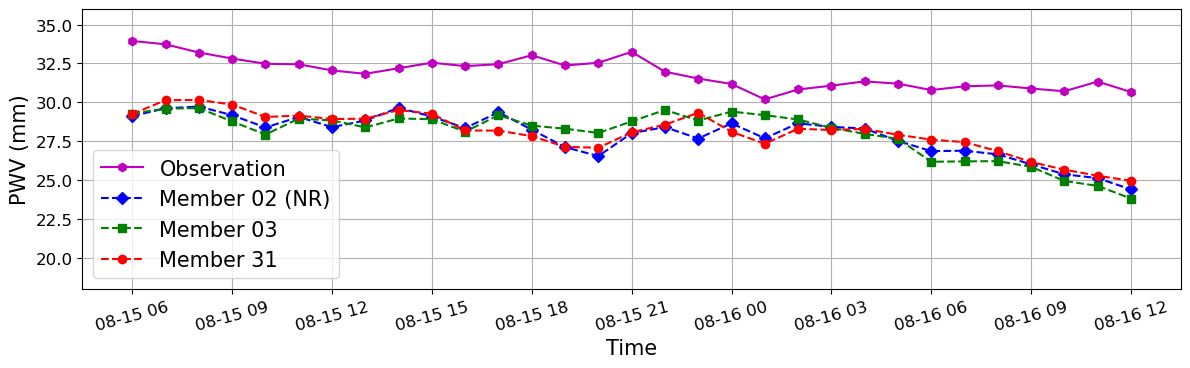

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

class PseudoPWVMerger:
    def __init__(self, pseudo_files, transds_pattern='TransDS_hr_2021*', output_dir='.'):
        self.pseudo_files = pseudo_files
        self.transds_files = sorted(glob.glob(transds_pattern))
        self.output_dir = output_dir
        self.mean_time_series = []

    def load_data(self):
        def extract_df(file):
            df = pd.read_csv(file, delim_whitespace=True, header=None)
            df = df[[1, 4, df.shape[1] - 1]]
            df.columns = ["Station", "Datetime", "Pseudo"]
            df["Datetime"] = pd.to_datetime(df["Datetime"].str.strip("[]"), utc=False)
            return df

        ens02 = extract_df(self.pseudo_files["ENS02"])
        ens03 = extract_df(self.pseudo_files["ENS03"])
        ens31 = extract_df(self.pseudo_files["ENS31"])

        merged_df = ens02.merge(ens03, on=["Station", "Datetime"], suffixes=("_ENS02", "_ENS03"))
        merged_df = merged_df.merge(ens31, on=["Station", "Datetime"])
        merged_df = merged_df.rename(columns={"Pseudo": "Pseudo_ENS31"})

        self.combined_df = merged_df

    def create_mean_time_series(self):
        grouped = self.combined_df.groupby("Datetime")

        if len(grouped) != len(self.transds_files):
            raise ValueError(f"Mismatch between datetime groups ({len(grouped)}) and TransDS files ({len(self.transds_files)}).")

        records = []
        for (dt, group), transds_file in zip(grouped, self.transds_files):
            transds = pd.read_csv(transds_file, delim_whitespace=True, header=None)
            transds.columns = ["Station", "Year", "MonthDay", "Hour", "Minute", "PWV_real"]

            merged = pd.merge(group, transds[["Station", "PWV_real"]], on="Station", how="inner")

            record = {
                "datetime": dt,
                "PWV_ENS02": merged["Pseudo_ENS02"].mean(),
                "PWV_ENS03": merged["Pseudo_ENS03"].mean(),
                "PWV_ENS31": merged["Pseudo_ENS31"].mean(),
                "PWV_real": merged["PWV_real"].mean()
                # "NODA": merged["NODA"].mean()  # optional if available
            }
            records.append(record)

        self.mean_time_series = pd.DataFrame(records)

    def plot_time_series(self, save_path="PWV_Plot_timeseries_mems.png"):
        if self.mean_time_series.empty:
            print("No data to plot. Run create_mean_time_series() first.")
            return

        data = self.mean_time_series
        plt.rcParams.update({'font.size': 15})
        plt.figure(figsize=(12, 4))

        plt.plot(data['datetime'], data['PWV_real'],  'm-h', label='Observation')
        plt.plot(data['datetime'], data['PWV_ENS02'], 'b--D', label='Member 02 (NR)')
        plt.plot(data['datetime'], data['PWV_ENS03'], 'g--s', label='Member 03')
        plt.plot(data['datetime'], data['PWV_ENS31'], 'r--o', label='Member 31')

        plt.xlabel('Time')
        plt.ylabel('PWV (mm)')
        plt.xticks(rotation=15)
        plt.ylim(18, 36)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_path, dpi=200)
        print(f"Saved plot to {save_path}")
        plt.show()

    def run_all(self):
        self.load_data()
        self.create_mean_time_series()
        self.plot_time_series(

# --- Usage ---
if __name__ == "__main__":
    pseudo_files = {
        "ENS02": "Synthetic_GPS_MET_station_pwv_CASE01_mem02_sam_Pseudo.dat",
        "ENS03": "Synthetic_GPS_MET_station_pwv_CASE01_mem03_sam_Pseudo.dat",
        "ENS31": "Synthetic_GPS_MET_station_pwv_CASE01_mem31_sam_Pseudo.dat"
    }

    merger = PseudoPWVMerger(pseudo_files)
    merger.run_all()

### 2. Elevation-dependent Bias Correction
First, we identified mean biases in the NR values across different station elevation bins of 0.5 km from the surface to 3 km throughout the assimilation window. Second, we corrected these elevation-dependent mean biases in the NR values and used these corrected values in all of the Data assimilation (DA) experiments by applying the terrain elevation-dependent bias corrections printed below. 

📂 Grouped into 7 time steps.
Saved plot: case01_bias_vs_altitude_plot_steve.png

 Mean Bias per Elevation Bin:
Elevation Bin (km)  Mean Bias (mm)
           0.0–0.5       -2.239455
           0.5–1.0       -2.267247
           1.0–1.5       -6.384081
           1.5–2.0       -5.274942
           2.0–2.5       -0.977399
           2.5–3.0        6.649233

 Saved mean bias data to: mean_bias_per_altitude_bin_steve.txt


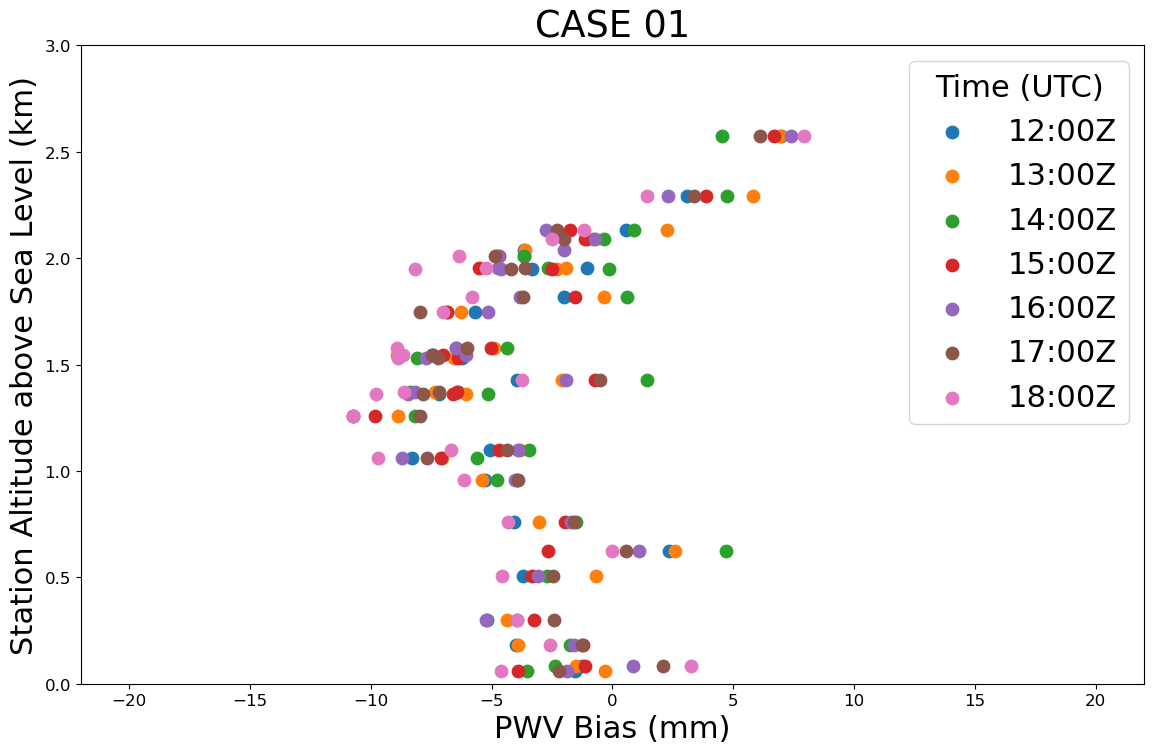

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

class PWVProcessor:
    def __init__(self, station_file, trans_ref_pattern, date_filter="20210815"):
        self.station_file = station_file
        self.trans_ref_pattern = trans_ref_pattern
        self.date_filter = date_filter
        self.grouped_data = {}
        self.processed_data = {}
        self.all_data = []

    def load_and_group_station_data(self):
        df = pd.read_csv(self.station_file, sep=',', header=None,
                         names=["alt", "names", "Longitude", "Latitude", "Datetime", "OSSE"])
        df["Datetime"] = df["Datetime"].apply(lambda x: x[0] if isinstance(x, list) else x)
        df["Datetime"] = pd.to_datetime(df["Datetime"].str.strip("[]"), infer_datetime_format=True)
        self.grouped_data = dict(tuple(df.groupby("Datetime")))
        print(f"📂 Grouped into {len(self.grouped_data)} time steps.")

    def merge_and_process(self):
        ref_files = sorted(glob.glob(self.trans_ref_pattern))
        if len(ref_files) != len(self.grouped_data):
            print("Mismatch: grouped data count ≠ reference file count.")
            return

        plt.figure(figsize=(12, 8))
        plt.rcParams.update({'font.size': 22})

        for datetime_key, ref_file in zip(sorted(self.grouped_data), ref_files):
            station_df = self.grouped_data[datetime_key]
            ref_df = pd.read_csv(ref_file, delim_whitespace=True, header=None)

            merged = pd.merge(
                station_df,
                ref_df[[0, ref_df.columns[-1]]],
                left_on="names",
                right_on=0,
                how="inner"
            )

            # Convert to numeric and calculate the difference (bias)
            merged.iloc[:, 5] = pd.to_numeric(merged.iloc[:, 5], errors='coerce')      # OSSE
            merged.iloc[:, -1] = pd.to_numeric(merged.iloc[:, -1], errors='coerce')    # REF value
            merged["bias"] = merged.iloc[:, -1] - merged.iloc[:, 5]

            self.processed_data[datetime_key] = merged

            # Extract hour for legend
            hour = datetime_key.strftime("%H")
            alt_km = merged["alt"] / 1000.0
            bias = merged["bias"] * -1  # Invert bias for plotting
            plt.scatter(bias, alt_km, label=f"{hour}:00Z", alpha=1, s=80)
            self.all_data.append(pd.DataFrame({'altitude_km': alt_km, 'bias': merged["bias"]}))

        plt.title("CASE 01")
        plt.xlabel("PWV Bias (mm)")
        plt.ylabel("Station Altitude above Sea Level (km)")
        plt.xlim(-22, 22)
        plt.ylim(0, 3)
        plt.legend(loc="upper right", title="Time (UTC)")
        plt.tight_layout()
        plt.savefig("case01_bias_vs_altitude_plot_steve.png", dpi=300)
        print("Saved plot: case01_bias_vs_altitude_plot_steve.png")

    def compute_and_save_mean_bias(self, output_file="mean_bias_per_altitude_bin_steve.txt"):
        combined_df = pd.concat(self.all_data, ignore_index=True)
        bins = np.arange(0, combined_df['altitude_km'].max() + 0.5, 0.5)
        labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]

        combined_df['alt_bin'] = pd.cut(combined_df['altitude_km'], bins=bins, labels=labels)
        mean_bias_per_bin = combined_df.groupby('alt_bin')['bias'].mean() * -1  # Invert to match plot

        # Create a DataFrame for cleaner table formatting
        result_df = mean_bias_per_bin.reset_index()
        result_df.columns = ["Elevation Bin (km)", "Mean Bias (mm)"]
        print("\n Mean Bias per Elevation Bin:")
        print(result_df.to_string(index=False))

        # Save to file
        result_df.to_csv(output_file, sep='\t', index=False)
        print(f"\n Saved mean bias data to: {output_file}")

# Run everything
if __name__ == "__main__":
    processor = PWVProcessor(
        station_file="Synthetic_GPS_MET_station_pwv_CASE01_mem02_real_pwv_stations_assimilation_hours.dat",
        trans_ref_pattern="TransDS_hr_2021*",
        date_filter="20210815"
    )
    processor.load_and_group_station_data()
    processor.merge_and_process()
    processor.compute_and_save_mean_bias()

### 3. DART Readable Synthetic Observations Generation
The main goal in this section is to generate hourly synthetic observation files from the NR that are readable by DART system to generate obs_sequence files that can be used during assimilation cycles to update the background field of the control-run (CR) ensembles

##### We take the file generated for ensemble member 02 (NR) and added noise to compare with real observation. for example: Synthetic_GPS_MET_station_pwv_CASE01_mem02_sam_Pseudo.dat

In [ ]:
import pandas as pd
import os

class PseudoPWVFormatter:
    def __init__(self, input_file):
        self.input_file = input_file
        self.df = None

    def load_and_parse_data(self):
        self.df = pd.read_csv(
            self.input_file,
            delim_whitespace=True,
            header=None,
            names=["Longitude", "Latitude", "Datetime", "true_NR", "pseudo"]
        )

        # Ensure station index is reset
        self.df.index = self.df.index.droplevel(0)
        self.df = self.df.rename_axis('station').reset_index()

        # Clean and convert datetime
        self.df["Datetime"] = self.df["Datetime"].apply(lambda x: x[0] if isinstance(x, list) else x)
        self.df["Datetime"] = pd.to_datetime(self.df["Datetime"].str.strip("[]"), infer_datetime_format=True)

    def format_and_save_groups(self, output_dir="."):
        grouped = self.df.groupby(self.df["Datetime"])

        for datetime, group in grouped:
            output_filename = datetime.strftime("Formated_Pseudo_Trans_CASE01_NR_mem02_SAM_hr_%Y%m%d%H.dat")
            full_path = os.path.join(output_dir, output_filename)

            formatted_rows = []
            for _, row in group.iterrows():
                station = row['station']
                dt = row['Datetime']
                pseudo = row['pseudo']

                year = dt.year
                monthday = dt.strftime('%m%d').lstrip('0')
                hour = f"{dt.hour:02d}"
                minute = f"{dt.minute:01d}"

                line = f"{station} {year} {monthday} {hour} {minute}         {pseudo:.1f}"
                formatted_rows.append(line)

            with open(full_path, "w") as f:
                f.write("\n".join(formatted_rows))

            print(f"Saved formatted file: {full_path}")

    def run(self, output_dir="."):
        self.load_and_parse_data()
        self.format_and_save_groups(output_dir)

# Example usage
if __name__ == "__main__":
    input_path = "Synthetic_GPS_MET_station_pwv_CASE01_mem02_sam_Pseudo.dat"
    formatter = PseudoPWVFormatter(input_path)
    formatter.run()

### 4. Setups of Different Observation Stations

##### Superobbed Station Creations

Loading WRF data...
Loading station files...
Plotting maps...


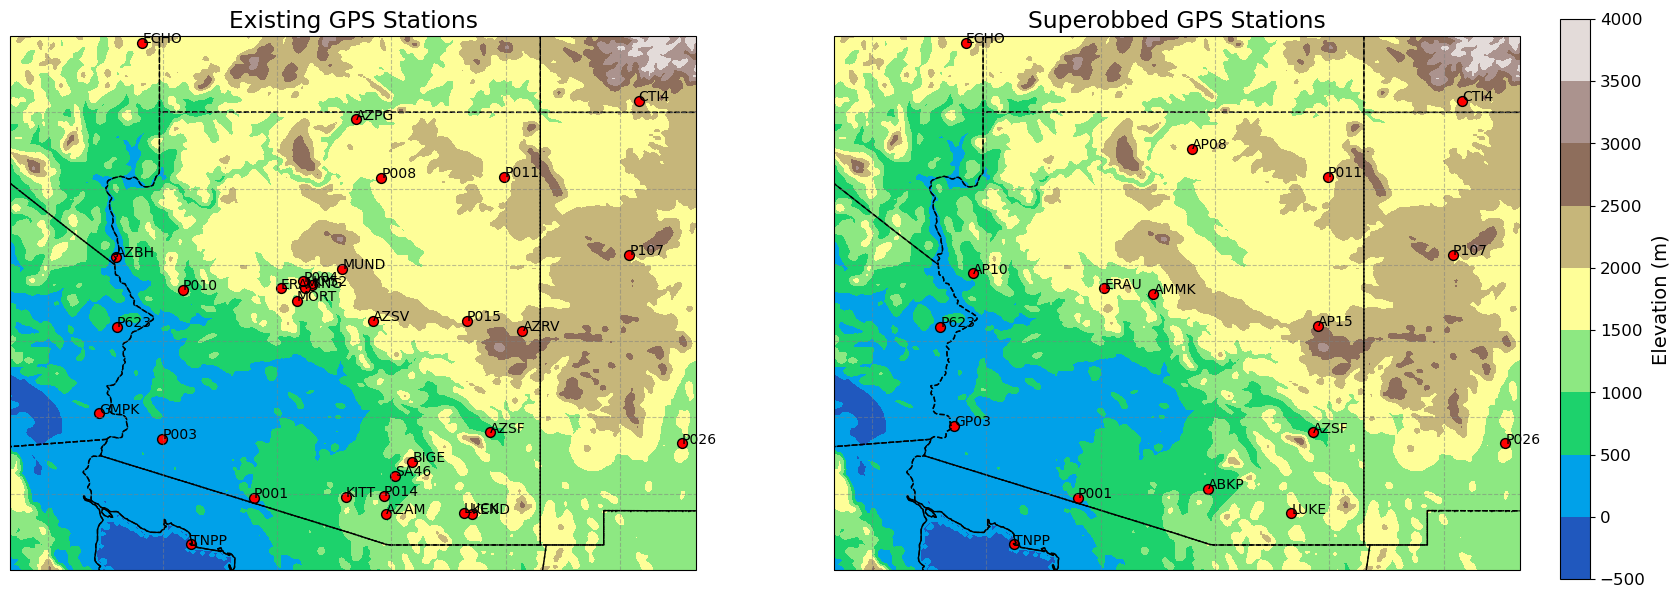

Saved: comparison_existing_vs_superobbed.png


In [26]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import warnings
warnings.filterwarnings('ignore')

class StationMapPlotter:
    def __init__(self, wrf_file, station_files, labels, extent=[-116, -107, 31, 38]):
        self.wrf_file = wrf_file
        self.station_files = station_files
        self.labels = labels
        self.extent = extent
        self.stations = []
        self.ds = None
        self.hgt = None
        self.lons = None
        self.lats = None

    def load_wrf_data(self):
        print("Loading WRF data...")
        self.ds = xr.open_dataset(self.wrf_file)
        self.hgt = self.ds['HGT'].isel(Time=0)
        self.lons = self.ds['XLONG'].isel(Time=0)
        self.lats = self.ds['XLAT'].isel(Time=0)

    def load_station_files(self):
        print("Loading station files...")
        for file in self.station_files:
            df = pd.read_csv(file, delim_whitespace=True,
                             names=['Longitude', 'Latitude', 'Altitude', 'Station'])
            self.stations.append(df)

    def plot_maps(self, output_filename="comparison_existing_vs_superobbed.png"):
        print("Plotting maps...")
        fig, axs = plt.subplots(1, 2, figsize=(20, 8),
                                subplot_kw={'projection': ccrs.PlateCarree()})
        plt.rcParams.update({'font.size': 14})
    
        for ax, df, label in zip(axs, self.stations, self.labels):
            ax.set_extent(self.extent)
            ax.add_feature(cf.COASTLINE)
            ax.add_feature(cf.BORDERS, linestyle=':')
            ax.add_feature(cf.STATES, linestyle='--')
            ax.gridlines(draw_labels=False, linestyle='--', color='gray', alpha=0.5)
    
            contour = ax.contourf(self.lons, self.lats, self.hgt,
                                  cmap='terrain', transform=ccrs.PlateCarree())
            ax.scatter(df['Longitude'], df['Latitude'], color='red', edgecolor='black',
                       s=50, label='Stations')
    
            for _, row in df.iterrows():
                ax.text(row['Longitude'], row['Latitude'], row['Station'],
                        fontsize=10, transform=ccrs.PlateCarree())
    
            ax.set_title(label)
    
        # Adjust space on the right for colorbar
        fig.subplots_adjust(right=0.88)
    
        # Create colorbar axes manually on the right
        cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
        cbar = fig.colorbar(contour, cax=cbar_ax)
        cbar.set_label('Elevation (m)', fontsize=14)
    
        plt.savefig(output_filename, dpi=300)
        plt.show()
        print(f"Saved: {output_filename}")

# --- Usage ---
plotter = StationMapPlotter(
    wrf_file='wrfout_d02_2021-08-15_12:00:00.nc',
    station_files=[
        'existing_GPS_DAVID-SUOMI_sites_2021.txt',
        'superobbed_GPS_DAVID-SUOMI_sites_2021.txt'
    ],
    labels=[
        'Existing GPS Stations',
        'Superobbed GPS Stations'
    ]
)
plotter.load_wrf_data()
plotter.load_station_files()
plotter.plot_maps()

##### Frequency distribution histogram of original and super-obbed stations

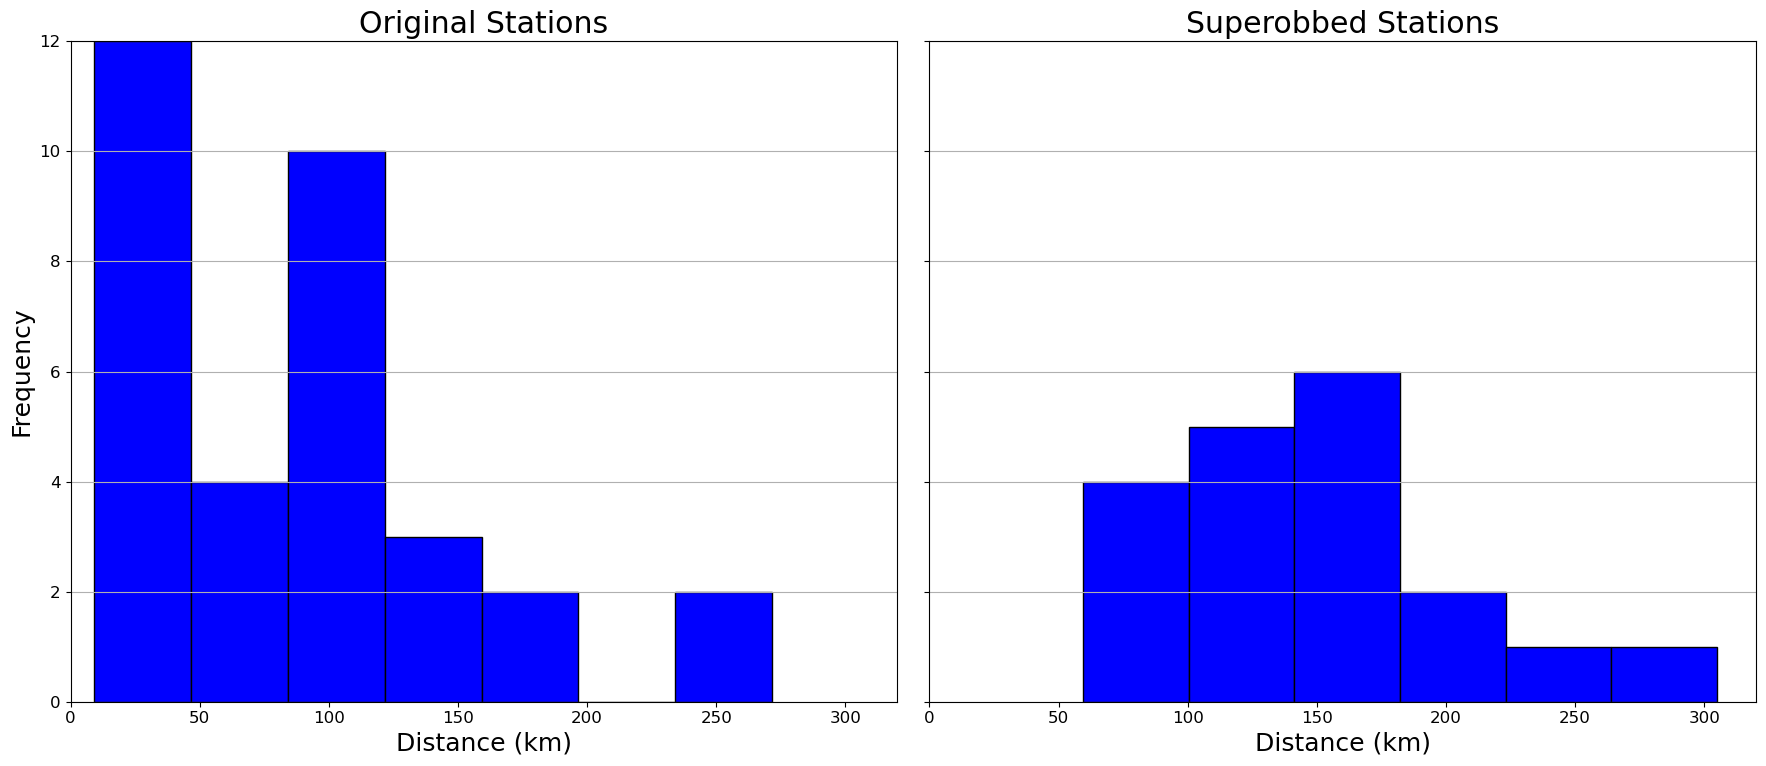

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from math import radians, sin, cos, sqrt, atan2

class Station:
    def __init__(self, name, lat, lon, height):
        self.name = name
        self.lat = lat
        self.lon = lon
        self.height = height

    def distance_to(self, other):
        # Convert latitude and longitude from degrees to radians
        lat1, lon1, lat2, lon2 = map(radians, [self.lat, self.lon, other.lat, other.lon])
        dh = (other.height - self.height) / 1000  # Convert height difference to kilometers

        # Haversine formula
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        R = 6371.0  # Radius of Earth in km

        return sqrt((R * c) ** 2 + dh ** 2)

class StationDistanceAnalyzer:
    def __init__(self, station_dict, label):
        self.stations = [Station(name, *info) for name, info in station_dict.items()]
        self.label = label
        self.min_distances = []

    def compute_min_distances(self):
        for i, station1 in enumerate(self.stations):
            min_distance = float('inf')
            for j, station2 in enumerate(self.stations):
                if i != j:
                    dist = station1.distance_to(station2)
                    if dist < min_distance:
                        min_distance = dist
            self.min_distances.append(min_distance)

# Define both station dictionaries
original_stations = {
    "AZAM": (31.730032, -111.071358, 958.24),
    "AZBH": (35.107494, -114.604988, 181.07),
    "AZPG": (36.908669, -111.462692, 1324.92),
    "AZRV": (34.131931, -109.281021, 2132.79),
    "AZSF": (32.802036, -109.711914, 923.64),
    "AZSV": (34.264996, -111.240517, 1489.61),
    "BIGE": (32.415997, -110.725592, 2572.44),
    "CTI4": (37.15292, -107.756088, 2036.07),
    "ECHO": (37.915531, -114.264252, 1706.33),
    "ERAU": (34.691, -112.4506, 1575.95),
    "GMPK": (33.051086, -114.827347, 624.46),
    "KEND": (31.7365, -109.9419, 1531.00),
    "KITT": (31.958111, -111.600395, 2090.19),
    "KP52": (34.7298, -112.0353, 1058.50),
    "LUCK": (31.7438, -110.052, 1370.00),
    "MING": (34.6974, -112.1277, 2291.30),
    "MORT": (34.52927, -112.2396, 1363.23),
    "MUND": (34.9456, -111.6402, 1949.35),
    "P001": (31.949375, -112.801704, 506.30),
    "P003": (32.722546, -114.004951, 83.39),
    "P004": (34.784382, -112.151985, 1816.44),
    "P008": (36.142822, -111.130051, 1544.57),
    "P010": (34.667263, -113.731346, 1427.85),
    "P011": (36.14983, -109.519226, 1747.55),
    "P014": (31.972895, -111.098595, 1098.61),
    "P015": (34.263809, -110.009483, 1953.67),
    "P026": (32.658962, -107.194878, 1260.31),
    "P107": (35.132179, -107.88002, 2011.30),
    "P623": (34.188934, -114.599403, 298.90),
    "SA46": (32.229839, -110.953926, 761.58),
    "TNHM": (29.081312, -110.970306, 206.28),
    "TNPP": (31.335518, -113.631638, 61.85),
    "USMX": (29.821653, -109.681053, 654.26),
}

superobbed_stations = {
    "ABKP": (32.061375, -111.089973, 1496.21),
    "AP10": (34.887378, -114.168167, 804.46),
    "AP08": (36.525745, -111.296371, 1434.75),
    "AP15": (34.197870, -109.645252, 2043.23),
    "AMMK": (34.619265, -111.806328, 1631.07),
    "GP03": (32.886815, -114.416149, 353.93),
    "LUKE": (31.740150, -109.996950, 1450.50),
    "AZSF": (32.802036, -109.711914, 923.64),
    "CTI4": (37.152920, -107.756088, 2036.07),
    "ECHO": (37.915531, -114.264252, 1706.33),
    "ERAU": (34.691000, -112.450600, 1575.95),
    "P001": (31.949375, -112.801704, 506.30),
    "P011": (36.149830, -109.519226, 1747.55),
    "P026": (32.658962, -107.194878, 1260.31),
    "P107": (35.132179, -107.880020, 2011.30),
    "P623": (34.188934, -114.599403, 298.90),
    "TNHM": (29.081312, -110.970306, 206.28),
    "TNPP": (31.335518, -113.631638, 61.85),
    "USMX": (29.821653, -109.681053, 654.26),
}

# Analyze both sets
original_analyzer = StationDistanceAnalyzer(original_stations, label='Original')
original_analyzer.compute_min_distances()

superobbed_analyzer = StationDistanceAnalyzer(superobbed_stations, label='Superobbed')
superobbed_analyzer.compute_min_distances()

# Plot side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
plt.rcParams.update({'font.size': 18})

axes[0].hist(original_analyzer.min_distances, bins='auto', color='blue', edgecolor='black')
axes[0].set_title('Original Stations')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 320)
axes[0].set_ylim(0, 12)
axes[0].grid(axis='y')

axes[1].hist(superobbed_analyzer.min_distances, bins='auto', color='blue', edgecolor='black')
axes[1].set_title('Superobbed Stations')
axes[1].set_xlabel('Distance (km)')
axes[1].set_xlim(0, 320)
axes[1].set_ylim(0, 12)
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig("side_by_side_station_spacing.png", dpi=300)
plt.show()

##### Uniform Stations Setup

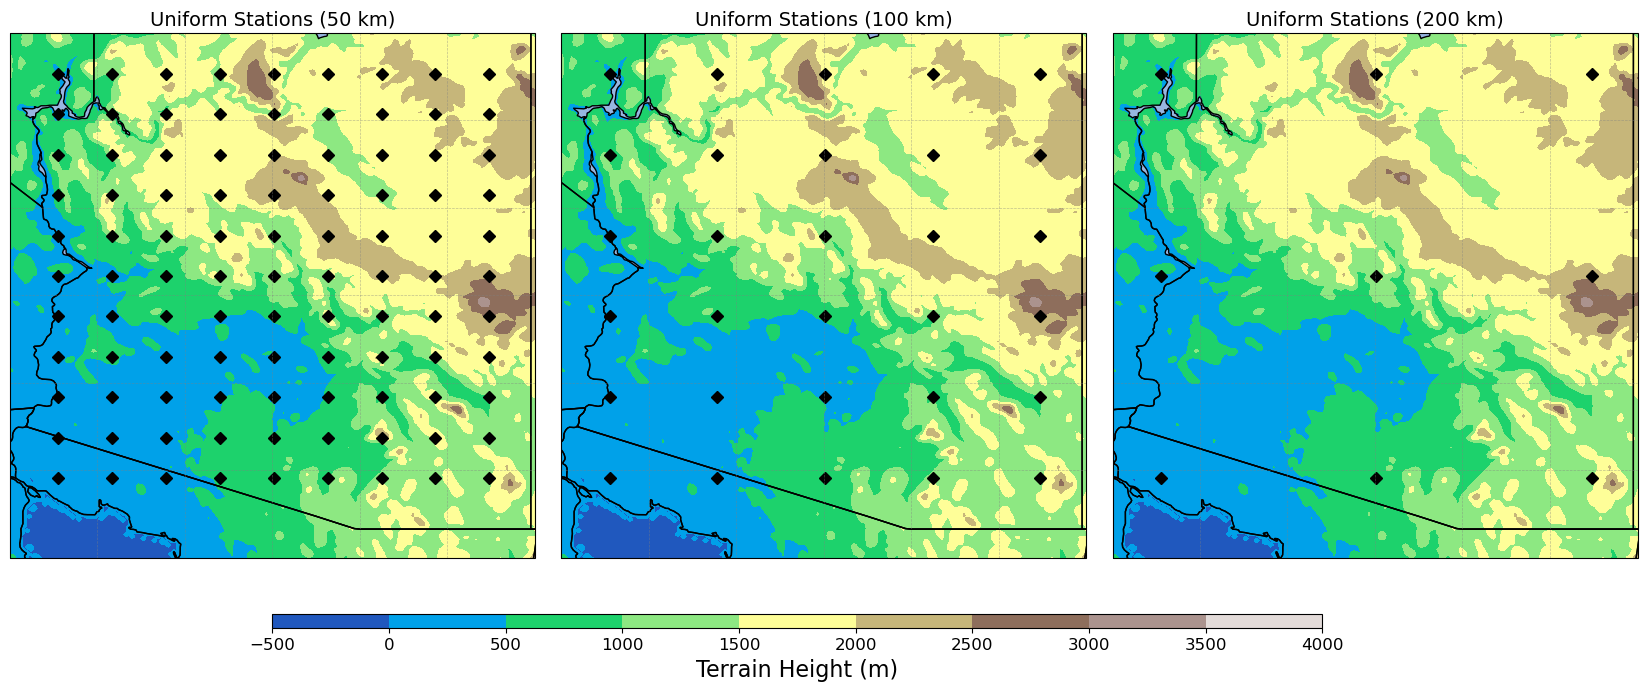

In [35]:
import numpy as np
import random
import string
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from math import radians, sin, cos, sqrt, atan2

class StationGridGenerator:
    def __init__(self, spacing_km, nc_data, output_file):
        self.spacing_km = spacing_km
        self.nc_data = nc_data
        self.output_file = output_file
        self.cord_top_left = (36.529554, -114.447008)
        self.cord_bottom_left = (31.911920, -114.600816)
        self.cord_top_right = (36.524095, -109.522887)
        random.seed(42)  # For reproducibility

    def generate_random_name(self, length=4):
        return ''.join(random.choices(string.ascii_uppercase, k=length))

    def haversine_distance(self, coord1, coord2):
        R = 6371.0  # Radius of Earth in km
        lat1, lon1 = map(radians, coord1)
        lat2, lon2 = map(radians, coord2)
        dlat = lat2 - lat1
        dlon = lon2 - lon1

        a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def calculate_steps(self, coord1, coord2):
        distance = self.haversine_distance(coord1, coord2)
        return int(distance // self.spacing_km)

    def generate_and_save(self):
        lat_steps = self.calculate_steps(self.cord_top_left, self.cord_bottom_left)
        lats = np.linspace(self.cord_top_left[0], self.cord_bottom_left[0], lat_steps + 1)

        lon_steps = self.calculate_steps(self.cord_top_left, self.cord_top_right)
        lons = np.linspace(self.cord_top_left[1], self.cord_top_right[1], lon_steps + 1)

        grid_points = [(lat, lon) for lat in lats for lon in lons]
        random_names = [self.generate_random_name() for _ in grid_points]

        elevations = []
        for lat, lon in grid_points:
            lat_index = np.abs(self.nc_data.variables['XLAT'][0, :, 0] - lat).argmin()
            lon_index = np.abs(self.nc_data.variables['XLONG'][0, 0, :] - lon).argmin()
            elevation = self.nc_data.variables['HGT'][0, lat_index, lon_index]
            elevations.append(elevation)

        with open(self.output_file, 'w') as file:
            file.write("lon lat altitude names\n")
            for (lat, lon), elevation, name in zip(grid_points, elevations, random_names):
                file.write(f"{lon:.6f} {lat:.6f} {elevation:.2f} {name}\n")

class StationMapPlotter:
    def __init__(self, hgt, xlat, xlong, station_files, titles):
        self.hgt = hgt
        self.xlat = xlat
        self.xlong = xlong
        self.station_files = station_files
        self.titles = titles

    def load_stations(self, file_path):
        data = []
        with open(file_path, 'r') as file:
            next(file)  # skip header
            for line in file:
                parts = line.split()
                lon, lat, elevation, name = float(parts[0]), float(parts[1]), float(parts[2]), parts[3]
                data.append((lon, lat, elevation, name))
        return data

    def plot_all(self):
        fig, axs = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.PlateCarree()})
        
        for ax, file, title in zip(axs, self.station_files, self.titles):
            ax.set_extent([-115, -109, 31, 37])
            ax.add_feature(cfeature.COASTLINE)
            ax.add_feature(cfeature.BORDERS)
            ax.add_feature(cfeature.STATES)
            ax.add_feature(cfeature.LAND, edgecolor='black')
            ax.add_feature(cfeature.OCEAN)
            ax.add_feature(cfeature.LAKES, edgecolor='black')
            
            # Gridlines without labels
            gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    
            cs = ax.contourf(self.xlong, self.xlat, self.hgt, cmap='terrain', transform=ccrs.PlateCarree())
            
            stations = self.load_stations(file)
            for lon, lat, ele, name in stations:
                ax.plot(lon, lat, 'kD', transform=ccrs.PlateCarree())
            
            ax.set_title(title, fontsize=14)
    
        fig.subplots_adjust(bottom=0.18, top=0.93, wspace=0.05)
    
        # Shared colorbar
        cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
        cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal', pad=0.05)
        cbar.set_label('Terrain Height (m)', fontsize=16)
    
        plt.savefig('synthetic_stations_comparison.jpg', dpi=300, bbox_inches='tight')
        plt.show()

# === Main Execution ===
if __name__ == "__main__":
    nc_file_path = "wrfout_d02_2021-08-15_12:00:00.nc"
    nc_data = Dataset(nc_file_path, "r")

    output_files = []
    spacings = [50, 100, 200]
    for spacing in spacings:
        output_file = f"coordinates_with_elevations_and_names_{spacing}km.txt"
        generator = StationGridGenerator(spacing_km=spacing, nc_data=nc_data, output_file=output_file)
        generator.generate_and_save()
        output_files.append(output_file)

    HGT = nc_data.variables['HGT'][0, :, :]
    XLAT = nc_data.variables['XLAT'][0, :, :]
    XLONG = nc_data.variables['XLONG'][0, :, :]
    nc_data.close()

    titles = ['Uniform Stations (50 km)', 'Uniform Stations (100 km)', 'Uniform Stations (200 km)']
    plotter = StationMapPlotter(HGT, XLAT, XLONG, output_files, titles)
    plotter.plot_all()

##### Qvapor moisture ground to 3km from NR to determine suitable vertical localization

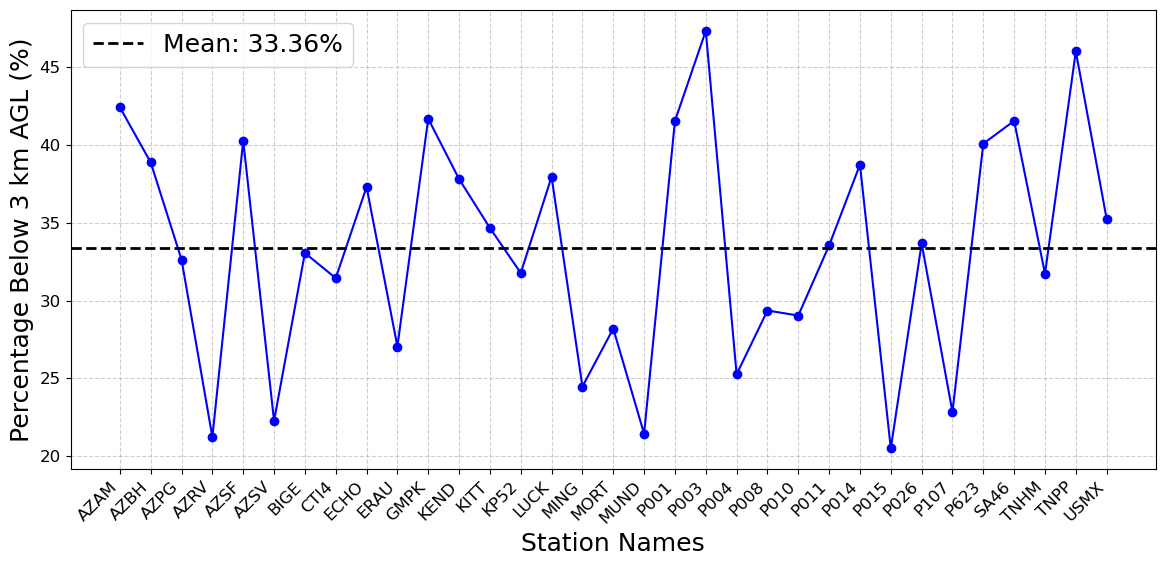

In [39]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class QvaporFractionAnalyzer:
    def __init__(self, wrf_file, stations):
        self.wrf_file = wrf_file
        self.stations = stations
        self.g = 9.81
        self.ds = None
        self.lat = None
        self.lon = None
        self.results = []
        self.station_names = []
        self.fractions = []

    def load_data(self):
        self.ds = xr.open_dataset(self.wrf_file)
        self.lat = self.ds['XLAT'][0, :, :]
        self.lon = self.ds['XLONG'][0, :, :]

    def find_nearest_grid_point(self, lat_pt, lon_pt):
        dist2 = (self.lat - lat_pt)**2 + (self.lon - lon_pt)**2
        j, i = np.unravel_index(np.argmin(dist2.values), dist2.shape)
        return j, i

    def extract_profile(self, j, i):
        qvapor = self.ds['QVAPOR'][0, :, j, i].values * 1000  # g/kg
        ph = self.ds['PH'][0, :, j, i].values
        phb = self.ds['PHB'][0, :, j, i].values
        z_stag = (ph + phb) / self.g
        z_full = 0.5 * (z_stag[:-1] + z_stag[1:])
        z_agl = z_full - z_full[0]
        return z_agl, qvapor

    def compute_fraction_below_3p5km(self, z_agl, qvapor):
        total = np.trapz(qvapor, z_agl)
        below = np.trapz(qvapor[z_agl <= 3000], z_agl[z_agl <= 3000])
        return below / total if total != 0 else np.nan

    def process_all_stations(self):
        for lon_pt, lat_pt, elev, name in self.stations:
            j, i = self.find_nearest_grid_point(lat_pt, lon_pt)
            z_agl, qvapor = self.extract_profile(j, i)
            fraction = self.compute_fraction_below_3p5km(z_agl, qvapor)
            self.fractions.append(fraction)
            self.station_names.append(name)
            self.results.append((name, lat_pt, lon_pt, elev, fraction))

    def get_dataframe(self):
        return pd.DataFrame(self.results, columns=["Station", "Latitude", "Longitude", "Elevation (m)", "Fraction <3km"])

    def plot_percentages(self, save_path='station_superobbed_qvapor_percentages_with_mean.jpg'):
        percentages = [100 - f * 100 for f in self.fractions]
        mean_percentage = np.nanmean(percentages)

        plt.rcParams.update({'font.size': 18})
        plt.figure(figsize=(12, 6))
        plt.plot(self.station_names, percentages, marker='o', linestyle='-', color='b')
        plt.axhline(y=mean_percentage, color='k', linestyle='--', linewidth=2, label=f'Mean: {mean_percentage:.2f}%')
        plt.xlabel('Station Names')
        plt.ylabel('Percentage Below 3 km AGL (%)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_path, dpi=360, bbox_inches='tight')
        plt.show()

# --- Updated Station List
station_list = [
    (-111.071358, 31.730032,  958.24, "AZAM"),
    (-114.604988, 35.107494,  181.07, "AZBH"),
    (-111.462692, 36.908669, 1324.92, "AZPG"),
    (-109.281021, 34.131931, 2132.79, "AZRV"),
    (-109.711914, 32.802036,  923.64, "AZSF"),
    (-111.240517, 34.264996, 1489.61, "AZSV"),
    (-110.725592, 32.415997, 2572.44, "BIGE"),
    (-107.756088, 37.152920, 2036.07, "CTI4"),
    (-114.264252, 37.915531, 1706.33, "ECHO"),
    (-112.450600, 34.691000, 1575.95, "ERAU"),
    (-114.827347, 33.051086,  624.46, "GMPK"),
    (-109.941900, 31.736500, 1531.00, "KEND"),
    (-111.600395, 31.958111, 2090.19, "KITT"),
    (-112.035300, 34.729800, 1058.50, "KP52"),
    (-110.052000, 31.743800, 1370.00, "LUCK"),
    (-112.127700, 34.697400, 2291.30, "MING"),
    (-112.239600, 34.529270, 1363.23, "MORT"),
    (-111.640200, 34.945600, 1949.35, "MUND"),
    (-112.801704, 31.949375,  506.30, "P001"),
    (-114.004951, 32.722546,   83.39, "P003"),
    (-112.151985, 34.784382, 1816.44, "P004"),
    (-111.130051, 36.142822, 1544.57, "P008"),
    (-113.731346, 34.667263, 1427.85, "P010"),
    (-109.519226, 36.149830, 1747.55, "P011"),
    (-111.098595, 31.972895, 1098.61, "P014"),
    (-110.009483, 34.263809, 1953.67, "P015"),
    (-107.194878, 32.658962, 1260.31, "P026"),
    (-107.880020, 35.132179, 2011.30, "P107"),
    (-114.599403, 34.188934,  298.90, "P623"),
    (-110.953926, 32.229839,  761.58, "SA46"),
    (-110.970306, 29.081312,  206.28, "TNHM"),
    (-113.631638, 31.335518,   61.85, "TNPP"),
    (-109.681053, 29.821653,  654.26, "USMX")
]
# --- Run Analysis
analyzer = QvaporFractionAnalyzer("wrfout_d02_2021-08-15_18:00:00", station_list)
analyzer.load_data()
analyzer.process_all_stations()
analyzer.plot_percentages()

# Optional: Print or export the table
df = analyzer.get_dataframe()
#print(df.to_string(index=False))

### 5. Synoptic Overview of the two North American Monsson (NAM) Cases

##### HRRR 500 mb Map

Processing: hrrr.t06z_20210815.wrfprsf12_18.grib2


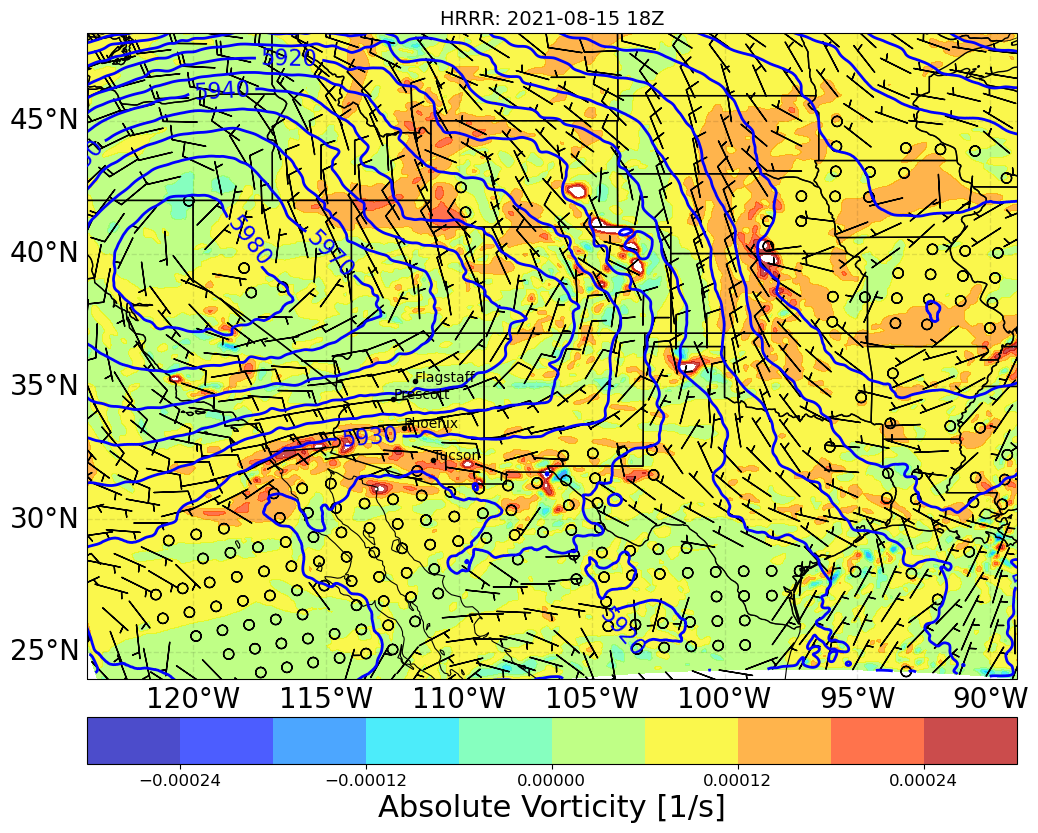

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import cartopy.crs as ccrs
import cartopy.feature as cf
from netCDF4 import Dataset
import pygrib
import glob
from datetime import datetime

class WeatherMapPlotter:
    def __init__(self, nc_file, grib_pattern):
        self.nc_file = nc_file
        self.grib_files = sorted(glob.glob(grib_pattern))
        self.lat = None
        self.lon = None
        self._load_latlon()

    def _load_latlon(self):
        with Dataset(self.nc_file, 'r') as nc:
            self.lat = nc.variables['gridlat_0'][:]
            self.lon = nc.variables['gridlon_0'][:]

    def _extract_grib_data(self, grb, name, level):
        try:
            var = grb.select(name=name, typeOfLevel='isobaricInhPa', level=level)
            if not var:
                raise ValueError(f"{name} not found at {level} hPa")
            return var[0].values
        except Exception as e:
            raise ValueError(f"Failed to extract {name}: {e}")

    def process_file(self, filepath):
        try:
            with pygrib.open(filepath) as grb:
                vorticity = self._extract_grib_data(grb, 'Absolute vorticity', 500)
                geopot = self._extract_grib_data(grb, 'Geopotential height', 500)
                u_wind = self._extract_grib_data(grb, 'U component of wind', 500)
                v_wind = self._extract_grib_data(grb, 'V component of wind', 500)

            return {
                'vorticity': gaussian_filter(vorticity, sigma=1),
                'geopot': geopot,
                'u_wind': gaussian_filter(u_wind, sigma=1),
                'v_wind': gaussian_filter(v_wind, sigma=1),
            }
        except Exception as e:
            print(f"Error processing {filepath}: {e}")
            return None

    def _parse_datetime(self, filename):
        date = datetime.strptime(filename[10:18], '%Y%m%d')
        hour = filename[29:31]
        return f"{date.strftime('%Y-%m-%d')} {hour}Z"

    def _add_cities(self, ax):
        cities = {
            'Phoenix': (-112.07, 33.44),
            'Tucson': (-110.97, 32.25),
            'Prescott': (-112.46, 34.54),
            'Flagstaff': (-111.65, 35.19)
        }
        for city, (lon, lat) in cities.items():
            ax.plot(lon, lat, 'k.', transform=ccrs.PlateCarree())
            ax.text(lon, lat, city, fontsize=10, transform=ccrs.PlateCarree())

    def plot(self, data, title_time, output_file):
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        plt.rcParams.update({'font.size': 20})
        ax.set_extent([-124, -89, 47, 24])
        ax.add_feature(cf.BORDERS, linewidth=0.5)
        ax.coastlines('50m', linewidth=0.8)
        ax.add_feature(cf.STATES, edgecolor="k")
        self._add_cities(ax)

        ax.set_title(f'HRRR: {title_time}', fontsize=14)
        gl = ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.1, linestyle='--')
        gl.top_labels = gl.right_labels = False

        vorticity_pc = ax.contourf(self.lon, self.lat, data['vorticity'], cmap='jet', alpha=0.7,
                                   levels=np.linspace(-3e-4, 3e-4, 11))
        cbar = fig.colorbar(vorticity_pc, ax=ax, orientation='horizontal', fraction=0.08, pad=0.05)
        cbar.set_label('Absolute Vorticity [1/s]', fontsize=22)

        geopot_contour = ax.contour(self.lon, self.lat, data['geopot'],
                                    levels=np.arange(5200, 6000, 10), colors='blue', linewidths=2)
        ax.clabel(geopot_contour, inline=True, fontsize=16, fmt='%d')

        ax.barbs(self.lon[::35, ::35], self.lat[::35, ::35],
                 data['u_wind'][::35, ::35], data['v_wind'][::35, ::35],
                 length=7, color='k', transform=ccrs.PlateCarree())

        fig.savefig(output_file, dpi=360, bbox_inches='tight')
        plt.show()

    def run(self):
        for file in self.grib_files:
            print(f"Processing: {file}")
            data = self.process_file(file)
            if data is not None:
                title = self._parse_datetime(file)
                output_name = f'500mb_weather_map_{file.split("/")[-1]}.jpg'
                self.plot(data, title, output_name)
# Example usage:
if __name__ == "__main__":
    plotter = WeatherMapPlotter(nc_file='hrrr.t06z.wrfsfcf06_12.nc', grib_pattern='*.grib2')
    plotter.run()

##### GFS bulk shear difference between Case 01 and Case 02
(a) 700–400 mb Bulk Shear Difference;
(b) 850–400 mb Bulk Shear Difference

Comparing:
  gfs_4_2021081618_1200_006.grb2
− gfs_4_2021081518_1200_006.grb2


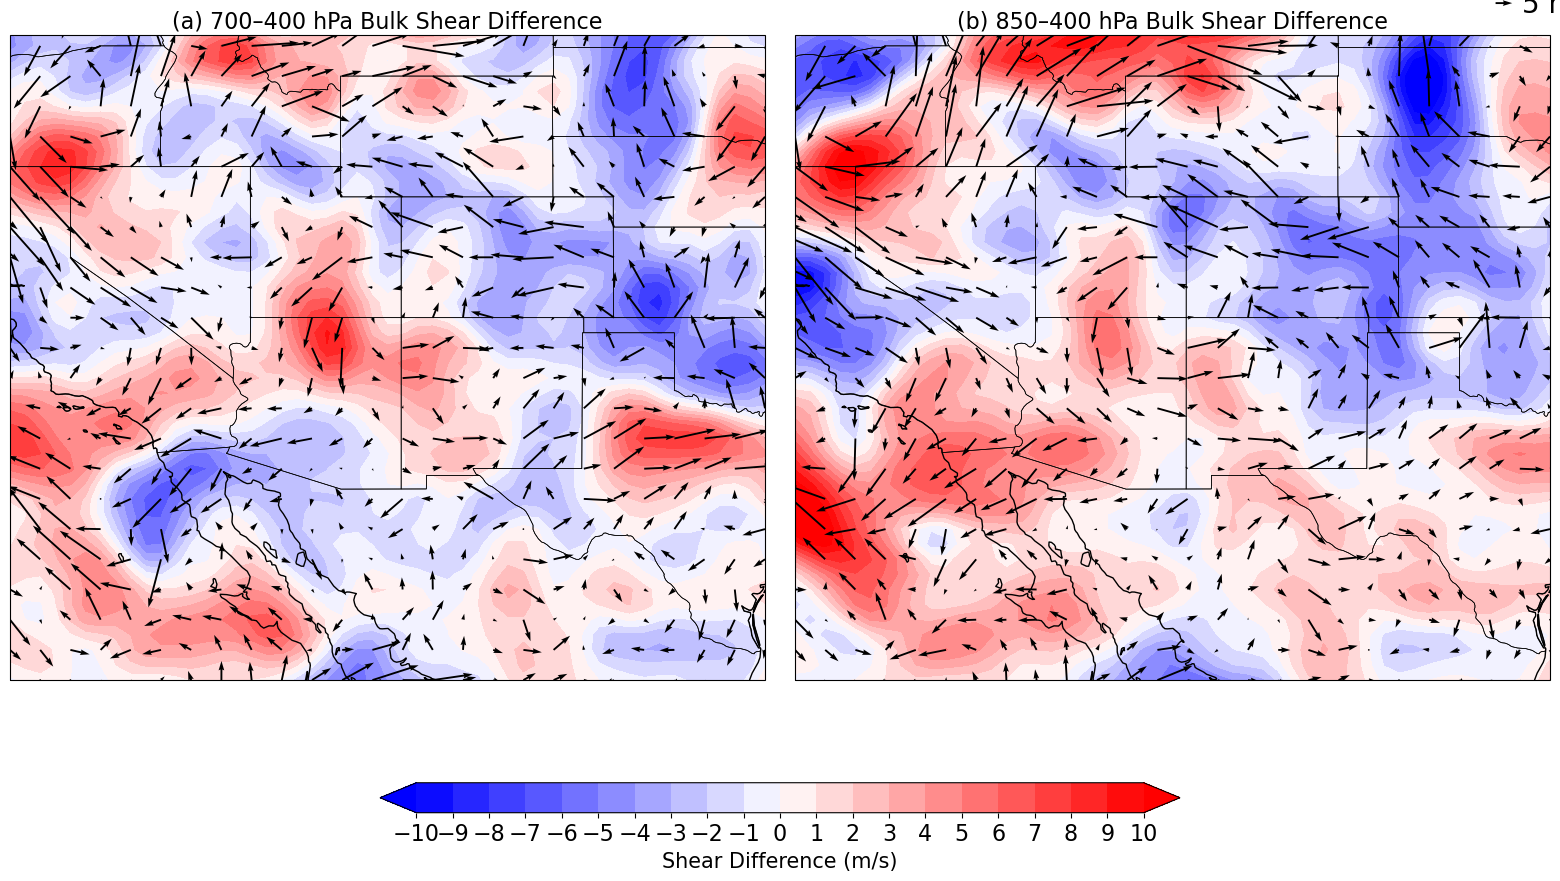

  → Saved: bulk_shear_diff_gfs_4_2021081618_1200_006_minus_gfs_4_2021081518_1200_006.png


In [44]:
import pygrib
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter
import os


class ShearDifferencePlotter:
    def __init__(self, file1, file2):
        self.file1 = file1
        self.file2 = file2
        self.extent = [-122, -97, 46, 25]
        self.levels = np.arange(-10, 11, 1)
        self.cmap = 'bwr'
        self.output_file = f"bulk_shear_diff_{self._basename(file1)}_minus_{self._basename(file2)}.png"

    def _basename(self, path):
        return os.path.basename(path).replace('.grb2', '')

    def _get_wind(self, grbs, level, type_of_level='isobaricInhPa'):
        u = grbs.select(name='U component of wind', typeOfLevel=type_of_level, level=level)[0]
        v = grbs.select(name='V component of wind', typeOfLevel=type_of_level, level=level)[0]
        return u.values, v.values, u.latlons()

    def _compute_shear_components(self, grib_file):
        with pygrib.open(grib_file) as grbs:
            u_700, v_700, (lat, lon) = self._get_wind(grbs, 700)
            u_400, v_400, _ = self._get_wind(grbs, 400)
            u_850, v_850, _ = self._get_wind(grbs, 850)

        def shear(u_top, v_top, u_bot, v_bot):
            du = u_top - u_bot
            dv = v_top - v_bot
            mag = np.sqrt(du ** 2 + dv ** 2)
            return du, dv, mag

        du_700_400, dv_700_400, mag_700_400 = shear(u_400, v_400, u_700, v_700)
        du_850_400, dv_850_400, mag_850_400 = shear(u_400, v_400, u_850, v_850)

        return (du_700_400, dv_700_400, mag_700_400,
                du_850_400, dv_850_400, mag_850_400,
                lat, lon)

    def plot_difference(self):
        print(f"Comparing:\n  {self.file1}\n− {self.file2}")

        # Compute shear components
        (du1_700_400, dv1_700_400, mag1_700_400,
         du1_850_400, dv1_850_400, mag1_850_400,
         lat, lon) = self._compute_shear_components(self.file1)

        (du2_700_400, dv2_700_400, mag2_700_400,
         du2_850_400, dv2_850_400, mag2_850_400,
         _, _) = self._compute_shear_components(self.file2)

        # Compute differences
        diff_mag_700_400 = gaussian_filter(mag1_700_400 - mag2_700_400, sigma=1)
        diff_mag_850_400 = gaussian_filter(mag1_850_400 - mag2_850_400, sigma=1)
        diff_du_700_400 = du1_700_400 - du2_700_400
        diff_dv_700_400 = dv1_700_400 - dv2_700_400
        diff_du_850_400 = du1_850_400 - du2_850_400
        diff_dv_850_400 = dv1_850_400 - dv2_850_400

        # Plot
        fig, axs = plt.subplots(1, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})

        # Panel (a): 700–400 hPa
        cf1 = axs[0].contourf(lon, lat, diff_mag_700_400, levels=self.levels, cmap=self.cmap, extend='both')
        q1 = axs[0].quiver(lon[::2, ::2], lat[::2, ::2], diff_du_700_400[::2, ::2], diff_dv_700_400[::2, ::2],
                           scale=30, scale_units='inches', width=0.0025)
        axs[0].set_title("(a) 700–400 hPa Bulk Shear Difference", fontsize=16)
        axs[0].set_extent(self.extent)
        axs[0].coastlines(); axs[0].add_feature(cfeature.BORDERS, linewidth=0.5); axs[0].add_feature(cfeature.STATES, linewidth=0.5)
        axs[0].tick_params(labelsize=16)

        # Panel (b): 850–400 hPa
        cf2 = axs[1].contourf(lon, lat, diff_mag_850_400, levels=self.levels, cmap=self.cmap, extend='both')
        q2 = axs[1].quiver(lon[::2, ::2], lat[::2, ::2], diff_du_850_400[::2, ::2], diff_dv_850_400[::2, ::2],
                           scale=30, scale_units='inches', width=0.0025)
        axs[1].set_title("(b) 850–400 hPa Bulk Shear Difference", fontsize=16)
        axs[1].set_extent(self.extent)
        axs[1].coastlines(); axs[1].add_feature(cfeature.BORDERS, linewidth=0.5); axs[1].add_feature(cfeature.STATES, linewidth=0.5)
        axs[1].tick_params(labelsize=16)

        # Colorbar
        cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.03])
        cbar = fig.colorbar(cf2, cax=cbar_ax, orientation='horizontal',
                            label='Shear Difference (m/s)', ticks=np.arange(-10, 11, 1))
        cbar.ax.tick_params(labelsize=16)
        cbar.set_label('Shear Difference (m/s)', fontsize=15)

        # Quiver key
        axs[1].quiverkey(q2, 0.95, 1.05, 5, '5 m/s', labelpos='E')

        plt.tight_layout(rect=[0, 0.15, 1, 1])
        plt.savefig(self.output_file, dpi=150)
        plt.show()
        print(f"  → Saved: {self.output_file}")


# Example usage
if __name__ == "__main__":
    file_a = "gfs_4_2021081618_1200_006.grb2"
    file_b = "gfs_4_2021081518_1200_006.grb2"
    plotter = ShearDifferencePlotter(file_a, file_b)
    plotter.plot_difference()

##### HRRR Most Unstable Convective Available Potential Energy (MUCAPE) at 2021-08-15:18Z

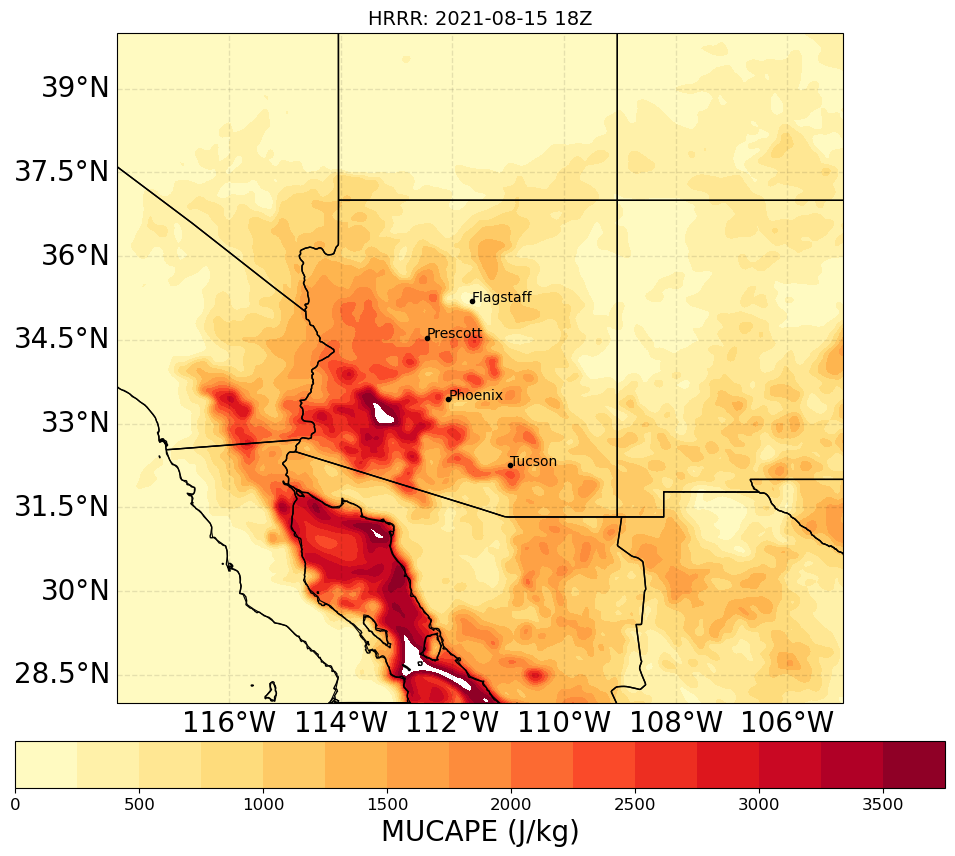

In [70]:
import os
import glob
import numpy as np
from scipy.ndimage import gaussian_filter
import pygrib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
from netCDF4 import Dataset
from datetime import datetime

class CAPEPlotter:
    def __init__(self, nc_file, grib_pattern='*.grib2'):
        self.nc_file = nc_file
        self.filelist = sorted(glob.glob(grib_pattern))
        self.lat, self.lon = self._load_lat_lon()
        self.cities = {
            'Phoenix': (-112.07, 33.44),
            'Tucson': (-110.97, 32.25),
            'Prescott': (-112.46, 34.54),
            'Flagstaff': (-111.65, 35.19)
        }

    def _load_lat_lon(self):
        with Dataset(self.nc_file, 'r') as nc:
            lat = nc.variables['gridlat_0'][:]
            lon = nc.variables['gridlon_0'][:]
        return lat, lon

    def _extract_cape(self, grib_file):
        try:
            with pygrib.open(grib_file) as grb:
                cape_var = grb.select(
                    name='Convective available potential energy',
                    typeOfLevel='pressureFromGroundLayer',
                    level=25500
                )
                if not cape_var:
                    raise ValueError("CAPE data not found.")
                return cape_var[0].values
        except (IndexError, ValueError) as e:
            print(f"Error in {grib_file}: {e}")
            return None

    def _parse_time(self, filename):
        try:
            file_time = datetime.strptime(filename[10:18], '%Y%m%d')
            hour = filename[29:31]
            return f'{file_time.strftime("%Y-%m-%d")} {hour}Z'
        except Exception:
            return 'Unknown Time'

    def _plot_map(self, cape_data, title, output_name):
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        plt.rcParams.update({'font.size': 20})

        ax.set_extent([-118, -105, 40, 28])
        ax.add_feature(cf.BORDERS, linewidth=0.5)
        ax.coastlines('50m', linewidth=0.8)
        ax.add_feature(cf.STATES, edgecolor="k")

        for city, (lon, lat) in self.cities.items():
            ax.plot(lon, lat, 'k.', transform=ccrs.PlateCarree())
            ax.text(lon, lat, city, fontsize=10, transform=ccrs.PlateCarree())

        ax.set_title(f'HRRR: {title}', fontsize=14)

        gl = ax.gridlines(draw_labels=True, linewidth=1, color='black', alpha=0.1, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False

        cape_smooth = gaussian_filter(cape_data, sigma=2)
        contour = ax.contourf(self.lon, self.lat, cape_smooth,
                              levels=np.arange(0, 4000, 250),
                              cmap='YlOrRd', alpha=1)

        plt.colorbar(contour, ax=ax, orientation='horizontal', fraction=0.08, pad=0.05, label="MUCAPE (J/kg)")
        fig.savefig(output_name, dpi=360, bbox_inches='tight')
        plt.show()

    def run(self):
        for fl in self.filelist:
            cape_data = self._extract_cape(fl)
            if cape_data is None:
                continue

            title_time = self._parse_time(os.path.basename(fl))
            output_file = f'cape_weather_map_{os.path.basename(fl)}.jpg'
            self._plot_map(cape_data, title_time, output_file)

if __name__ == '__main__':
    cape_plotter = CAPEPlotter('hrrr.t06z.wrfsfcf06_12.nc')
    cape_plotter.run()

##### Precipitable Water Vapor (PWV) from NR at the end of DA Cycle for Case 01 overlapped with superobbed stations

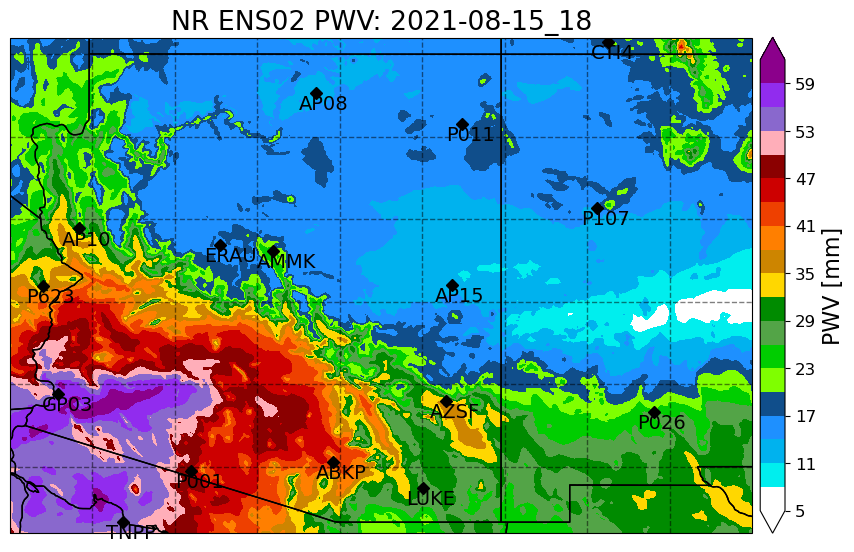

Saved: PWV_NR_2021-08-15_18.jpg


In [61]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import matplotlib as mplt
import cartopy.crs as ccrs
import cartopy.feature as cf
from matplotlib.colors import ListedColormap, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
import glob
import warnings
warnings.filterwarnings('ignore')

class WRFPWVPlotter:
    def __init__(self, nc_pattern='pwv_wrfout*'):
        self.filelist = sorted(glob.glob(nc_pattern))
        self.extent = [-115, -106, 31.2, 37.2]
        self.custom_x_ticks = [-115, -114, -113, -112, -111, -110, -109, -108, -107,-106]
        self.custom_y_ticks = [31.1, 32, 33, 34, 35, 36, 37, 37.5]
        self.levels = [5, 8, 11, 14, 17, 20, 23, 26, 29, 32,
                       35, 38, 41, 44, 47, 50, 53, 56, 59, 62]
        self.colours = ['white', '#00EEEE', '#00B2EE', '#1E90FF', '#104E8B',
                        '#7FFF00', '#00CD00', '#53a447', '#008B00', '#FFFF00',
                        '#FFD700', '#CD8500', '#FF7F00', '#EE4000', '#CD0000',
                        '#8B0000', '#FFAEB9', '#8968CD', '#912CEE', '#8B008B']
        self.cmap = ListedColormap(self.colours)
        self.norm = Normalize(vmin=5, vmax=62)
        self.city_markers = {
            'ABKP': (-111.089973, 32.061375),
            'AP10': (-114.168167, 34.887378),
            'AP08': (-111.296371, 36.525745),
            'AP15': (-109.645252, 34.197870),
            'AMMK': (-111.806328, 34.619265),
            'GP03': (-114.416149, 32.886815),
            'LUKE': (-109.996950, 31.740150),
            'AZSF': (-109.711914, 32.802036),
            'CTI4': (-107.756088, 37.152920),
            'ERAU': (-112.450600, 34.691000),
            'P001': (-112.801704, 31.949375),
            'P011': (-109.519226, 36.149830),
            'P026': (-107.194878, 32.658962),
            'P107': (-107.880020, 35.132179),
            'P623': (-114.599403, 34.188934),
            'TNPP': (-113.631638, 31.335518)
        }

    def run(self):
        for fl in self.filelist:
            self.plot_file(fl)

    def plot_file(self, filepath):
        with Dataset(filepath, "r") as nc:
            lat = nc.variables['XLAT'][:, 0]
            lon = nc.variables['XLONG'][0, :]
            var = nc.variables['PWV'][:, :]

        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
        plt.rcParams.update({'font.size': 16})
        mplt.rc('xtick', labelsize=12)
        mplt.rc('ytick', labelsize=12)
        ax.set_extent(self.extent)

        # Add map features
        ax.add_feature(cf.BORDERS, linewidth=0.5, edgecolor="k")
        ax.add_feature(cf.COASTLINE, edgecolor="k")
        ax.add_feature(cf.STATES, edgecolor="k")

        # Title
        title_str = f'NR ENS02 PWV: {filepath[15:28]}'
        ax.set_title(title_str)

        # Gridlines
        gl = ax.gridlines(draw_labels=False, linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.xlocator = mticker.FixedLocator(self.custom_x_ticks)
        gl.ylocator = mticker.FixedLocator(self.custom_y_ticks)
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER

        # Plot cities
        for city, (lon_c, lat_c) in self.city_markers.items():
            ax.plot(lon_c, lat_c, 'kD', transform=ccrs.PlateCarree())
            ax.text(lon_c - 0.2, lat_c - 0.2, city, transform=ccrs.PlateCarree(), fontsize=14)

        # PWV Contour
        pc = ax.contourf(lon, lat, var, levels=self.levels, cmap=self.cmap, norm=self.norm, extend='both')

        # Colorbar
        divider = make_axes_locatable(ax)
        cbar = fig.colorbar(pc, orientation="vertical", fraction=0.032, pad=0.01)
        cbar.set_label('PWV [mm]', fontsize=16)

        # Save figure
        save_name = f'PWV_NR_{filepath[15:28]}.jpg'
        fig.savefig(save_name, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"Saved: {save_name}")

# Example usage
if __name__ == "__main__":
    plotter = WRFPWVPlotter(nc_pattern='pwv_wrfout*')
    plotter.run()

### 6. Metrics and Evaluation Tools

#### Evaluation of OSSE Forecasts
##### Statistical comparison of real observations with different OSSE experiments
The synthetic observations are extracted from respective DA experiemnts for the locations of real PWV 2021 campaign stations to with compare with real PWV.

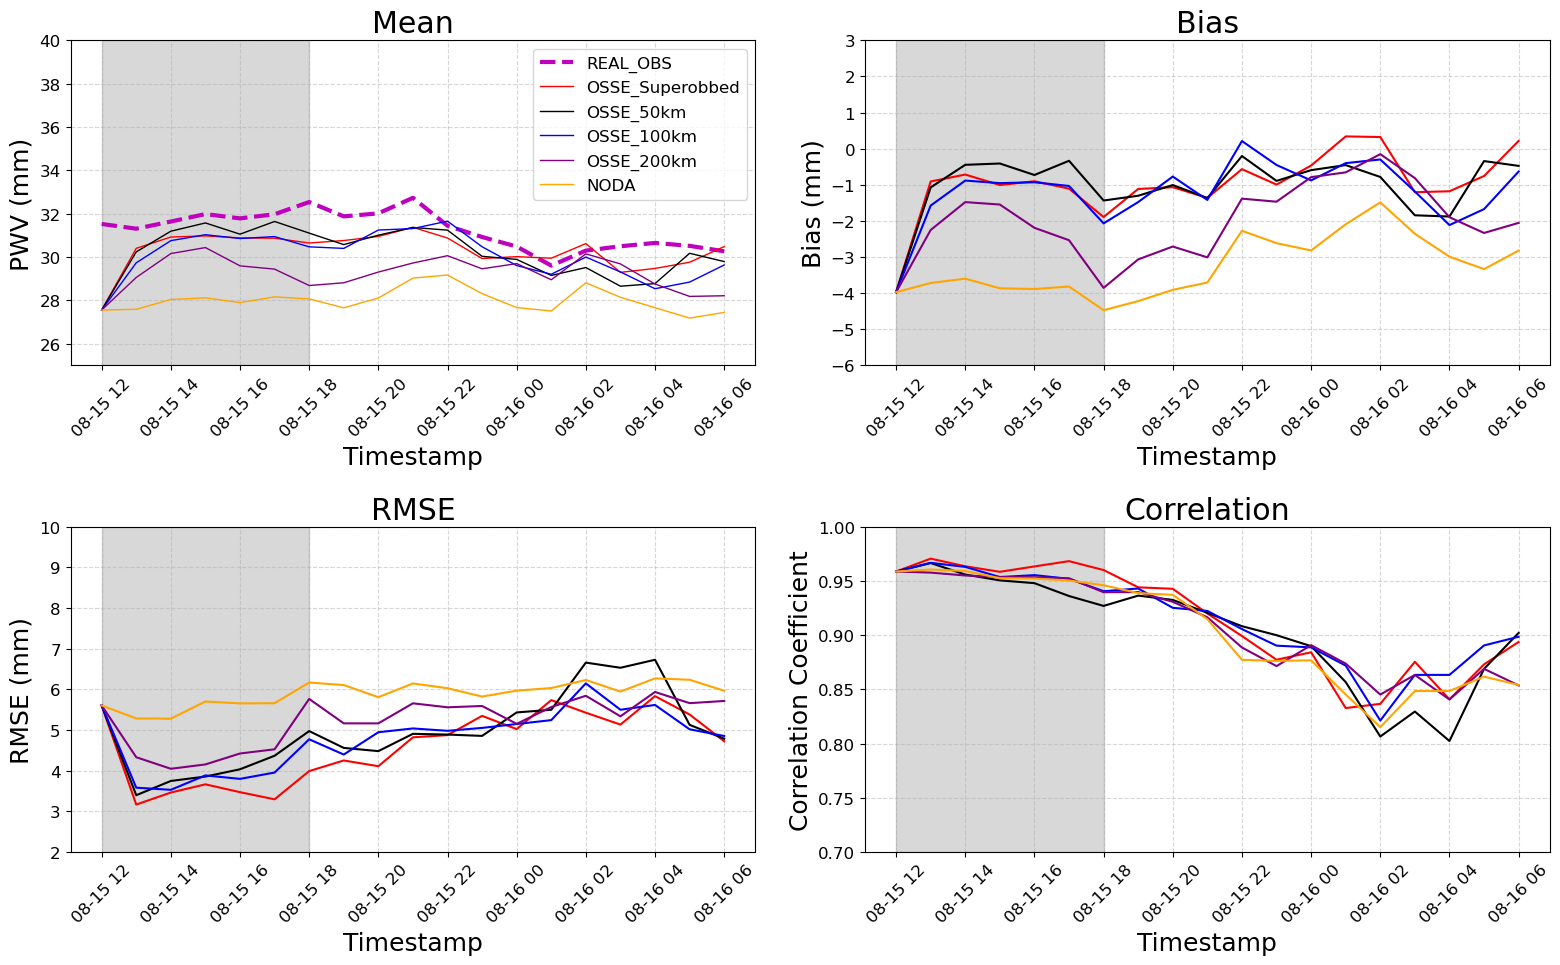

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from datetime import datetime, timedelta
from sklearn.metrics import mean_squared_error

class PWVAnalyzer:
    def __init__(self, pwv_file_map, transds_pattern="sorted_TransDS_hr_2021*.dat"):
        self.pwv_file_map = pwv_file_map
        self.transds_pattern = transds_pattern
        self.merged_data = pd.DataFrame()

    def load_and_merge(self):
        # Load base superobbing data
        base_df = pd.read_csv(self.pwv_file_map["superobbing"], delimiter=",", header=None)

        # Add other experiment columns (excluding NR)
        for label, path in self.pwv_file_map.items():
            if label == "superobbing":
                continue
            df = pd.read_csv(path, delimiter=",", header=None)
            base_df[label] = df.iloc[:, -1]

        base_df.columns = [
            "Altitude_Station", "Longitude", "Latitude", "Datetime", "superobbing",
            "NODA", "da_50km", "da_100km", "da_200km"
        ]
        base_df[["Altitude", "station"]] = base_df["Altitude_Station"].str.split(expand=True)
        base_df.drop(columns=["Altitude_Station"], inplace=True)

        base_df["Datetime"] = base_df["Datetime"].apply(lambda x: x[0] if isinstance(x, list) else x)
        base_df["Datetime"] = pd.to_datetime(base_df["Datetime"].str.strip("[]"), errors='coerce')
        base_df = base_df.dropna()

        grouped = base_df.groupby("Datetime")
        transds_files = sorted(glob.glob(self.transds_pattern))
        transds_dfs = {}

        for f in transds_files:
            try:
                tokens = f.split("_")[-1].split(".dat")[0].split(".")
                dt = datetime(int(tokens[0]), 1, 1) + timedelta(days=int(tokens[1]) - 1, hours=int(tokens[2]))
                transds_dfs[dt] = pd.read_csv(f, delimiter=' ', header=None)
            except Exception as e:
                print(f"Could not parse {f}: {e}")

        all_merged = []

        for dt, group in grouped:
            trans_df = transds_dfs.get(dt)
            if trans_df is None:
                print(f"No TransDS match for {dt}")
                continue
            try:
                merged = pd.merge(group, trans_df, left_on="station", right_on=0, how="inner")
                merged.rename(columns={merged.columns[-1]: "REAL_OBS"}, inplace=True)
                final = merged[["station", "Datetime", "superobbing", "NODA", "da_50km", "da_100km", "da_200km", "REAL_OBS"]]
                final.columns = ["StationID", "Timestamp", "OSSE_Superobbed", "NODA", "OSSE_50km", "OSSE_100km", "OSSE_200km", "REAL_OBS"]
                all_merged.append(final)
            except Exception as e:
                print(f"Merge failed for {dt}: {e}")

        if all_merged:
            self.merged_data = pd.concat(all_merged, ignore_index=True)
        else:
            raise ValueError("No successful merges found.")

    def compute_metrics(self):
        df = self.merged_data.copy()
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df = df.dropna(subset=[
            'Timestamp', 'OSSE_Superobbed', 'NODA', 'OSSE_50km', 'OSSE_100km', 'OSSE_200km', 'REAL_OBS'
        ])

        def safe_corrcoef(x, y):
            return np.corrcoef(x, y)[0, 1] if np.std(x) != 0 and np.std(y) != 0 else np.nan

        metrics = df.groupby("Timestamp").apply(lambda x: pd.Series({
            "Bias_OSSE_Superobbed": np.mean(x["OSSE_Superobbed"] - x["REAL_OBS"]),
            "Bias_OSSE_50km": np.mean(x["OSSE_50km"] - x["REAL_OBS"]),
            "Bias_OSSE_100km": np.mean(x["OSSE_100km"] - x["REAL_OBS"]),
            "Bias_OSSE_200km": np.mean(x["OSSE_200km"] - x["REAL_OBS"]),
            "Bias_NODA": np.mean(x["NODA"] - x["REAL_OBS"]),

            "RMSE_OSSE_Superobbed": np.sqrt(mean_squared_error(x["REAL_OBS"], x["OSSE_Superobbed"])),
            "RMSE_OSSE_50km": np.sqrt(mean_squared_error(x["REAL_OBS"], x["OSSE_50km"])),
            "RMSE_OSSE_100km": np.sqrt(mean_squared_error(x["REAL_OBS"], x["OSSE_100km"])),
            "RMSE_OSSE_200km": np.sqrt(mean_squared_error(x["REAL_OBS"], x["OSSE_200km"])),
            "RMSE_NODA": np.sqrt(mean_squared_error(x["REAL_OBS"], x["NODA"])),

            "Correlation_OSSE_Superobbed": safe_corrcoef(x["REAL_OBS"], x["OSSE_Superobbed"]),
            "Correlation_OSSE_50km": safe_corrcoef(x["REAL_OBS"], x["OSSE_50km"]),
            "Correlation_OSSE_100km": safe_corrcoef(x["REAL_OBS"], x["OSSE_100km"]),
            "Correlation_OSSE_200km": safe_corrcoef(x["REAL_OBS"], x["OSSE_200km"]),
            "Correlation_NODA": safe_corrcoef(x["REAL_OBS"], x["NODA"]),
        }))
        return df.groupby('Timestamp')[['REAL_OBS', 'OSSE_Superobbed', 'OSSE_50km', 'OSSE_100km', 'OSSE_200km', 'NODA']].mean(), metrics

    def plot_metrics(self, mean_vals, metrics):
        plt.figure(figsize=(16, 10))
        plt.rcParams.update({'font.size': 18})

        shade_start = datetime(2021, 8, 15, 12)
        shade_end = datetime(2021, 8, 15, 18)

        colors = {
            'REAL_OBS': 'm', 'OSSE_Superobbed': 'r', 'OSSE_50km': 'k',
            'OSSE_100km': 'b', 'OSSE_200km': 'purple', 'NODA': 'orange'
        }

        # 1. Mean
        plt.subplot(2, 2, 1)
        plt.axvspan(shade_start, shade_end, color='gray', alpha=0.3)
        for col in mean_vals.columns:
            ls = '--' if col == "REAL_OBS" else "-"
            lw = 3 if col == "REAL_OBS" else 1
            plt.plot(mean_vals.index, mean_vals[col], label=col, color=colors[col], linestyle=ls, linewidth=lw)
        plt.title("Mean")
        plt.ylabel("PWV (mm)")
        plt.xlabel("Timestamp")
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        plt.ylim(25, 40)

        # 2. Bias
        plt.subplot(2, 2, 2)
        plt.axvspan(shade_start, shade_end, color='gray', alpha=0.3)
        for sim in ['OSSE_Superobbed', 'OSSE_50km', 'OSSE_100km', 'OSSE_200km', 'NODA']:
            plt.plot(metrics.index, metrics[f"Bias_{sim}"], label=sim, color=colors[sim])
        plt.title("Bias")
        plt.ylabel("Bias (mm)")
        plt.xlabel("Timestamp")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        plt.ylim(-6, 3)

        # 3. RMSE
        plt.subplot(2, 2, 3)
        plt.axvspan(shade_start, shade_end, color='gray', alpha=0.3)
        for sim in ['OSSE_Superobbed', 'OSSE_50km', 'OSSE_100km', 'OSSE_200km', 'NODA']:
            plt.plot(metrics.index, metrics[f"RMSE_{sim}"], label=sim, color=colors[sim])
        plt.title("RMSE")
        plt.ylabel("RMSE (mm)")
        plt.xlabel("Timestamp")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        plt.ylim(2, 10)

        # 4. Correlation
        plt.subplot(2, 2, 4)
        plt.axvspan(shade_start, shade_end, color='gray', alpha=0.3)
        for sim in ['OSSE_Superobbed', 'OSSE_50km', 'OSSE_100km', 'OSSE_200km', 'NODA']:
            plt.plot(metrics.index, metrics[f"Correlation_{sim}"], label=sim, color=colors[sim])
        plt.title("Correlation")
        plt.ylabel("Correlation Coefficient")
        plt.xlabel("Timestamp")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.xticks(rotation=45)
        plt.ylim(0.7, 1)

        plt.tight_layout()
        plt.savefig("time_series_metrics_without_NR.jpg", dpi=360, bbox_inches='tight')
        plt.savefig("time_series_metrics_without_NR.pdf", bbox_inches='tight')
        plt.show()
if __name__ == "__main__":
    pwv_files = {
        "superobbing": "Synthetic_GPS_MET_station_pwv_CASE01_mem02_223km_3.5km_HBC.dat",
        "NODA": "Synthetic_GPS_MET_station_pwv_CASE01_NODA.dat",
        "da_50km": "Synthetic_GPS_MET_station_pwv_CASE01_mem02_223km_3.5km_HBC_50km.dat",
        "da_100km": "Synthetic_GPS_MET_station_pwv_CASE01_mem02_223km_3.5km_HBC_100km.dat",
        "da_200km": "Synthetic_GPS_MET_station_pwv_CASE01_mem02_223km_3.5km_HBC_200km.dat"
    }

    analyzer = PWVAnalyzer(pwv_files)
    analyzer.load_and_merge()
    mean_ts, metric_ts = analyzer.compute_metrics()
    analyzer.plot_metrics(mean_ts, metric_ts)

#### Precipitation Forecasts
##### 3 Hourly Accumulated Precipitation Comparison
1. Calculate hourly precipitation from WRFOUT files
2. Regrid to MRMS observations dimension
3. Accumulate 3 hours of precipitation in one file

##### 1. Calculate hourly precipitation from WRFOUT files

In [ ]:
import netCDF4 as nc
import glob

# Get a list of all NetCDF files in the directory
file_list = glob.glob('wrfout_d02*')

# Sort the file list to ensure proper order
file_list.sort()

# Iterate over each pair of consecutive files
for i in range(len(file_list) - 1):
    # Open the two input files
    file1 = nc.Dataset(file_list[i])
    file2 = nc.Dataset(file_list[i+1])

    # Get the variable objects
    var1 = file1.variables['RAINNC']
    var2 = file2.variables['RAINNC']

    # Subtract one variable from the other
    result = var2[:] - var1[:]

    # Create a new NetCDF file
    output_file =  '100km_hourly_' + file_list[i+1].split('/')[-1]

    with nc.Dataset(output_file, 'w', format='NETCDF4') as out_file:
        # Copy dimensions from one of the input files
        for dimname, dim in file1.dimensions.items():
            out_file.createDimension(dimname, len(dim) if not dim.isunlimited() else None)

        # Create variables in the output file
        out_var = out_file.createVariable('RAINNC', var1.datatype, var1.dimensions)

        # Copy attributes from one of the input variables
        out_var.setncatts({k: var1.getncattr(k) for k in var1.ncattrs()})

        # Write the result to the output file
        out_var[:] = result[:]

        # Copy XLAT and XLONG variables
        for var_name in ['XLAT', 'XLONG']:
            if var_name in file1.variables:
                var = file1.variables[var_name]
                out_var = out_file.createVariable(var_name, var.datatype, var.dimensions)
                out_var.setncatts({k: var.getncattr(k) for k in var.ncattrs()})
                out_var[:] = var[:]

    # Close the files
    file1.close()
    file2.close()

##### 2. Regrid to MRMS observations dimension

In [ ]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import glob
import re

# Define file patterns

wrf_files = sorted(glob.glob("100km_hourly*.nc"))  # Adjust pattern if needed
mrms_file = "MRMS_accumulated_precip_1518_1606.nc"

# Open MRMS dataset (fixed grid for all iterations)
mrms_ds = xr.open_dataset(mrms_file)
mrms_lons, mrms_lats = np.meshgrid(mrms_ds["lon_0"], mrms_ds["lat_0"])

# Loop over multiple WRF files
for wrf_file in wrf_files:
    print(f"Processing {wrf_file}...")

    # Open WRF dataset
    wrf_ds = xr.open_dataset(wrf_file)

    # Extract WRF precipitation data and coordinates
    wrf_data = wrf_ds["RAINNC"].squeeze()  # Remove time dimension if present
    wrf_lons, wrf_lats = wrf_ds["XLONG"].squeeze(), wrf_ds["XLAT"].squeeze()

    # Convert WRF longitudes from [-180, 180] to [0, 360] format
    wrf_lons = wrf_lons % 360

    # Flatten the WRF grid and data for interpolation
    wrf_points = np.column_stack((wrf_lons.values.ravel(), wrf_lats.values.ravel()))
    wrf_values = wrf_data.values.ravel().astype(float)

    # Remove NaN values before interpolation
    valid_mask = ~np.isnan(wrf_values)
    wrf_points = wrf_points[valid_mask]
    wrf_values = wrf_values[valid_mask]

    # Interpolate using nearest-neighbor method
    mrms_points = np.column_stack((mrms_lons.ravel(), mrms_lats.ravel()))
    regridded_values = griddata(wrf_points, wrf_values, mrms_points, method='nearest')

    # Reshape back to MRMS grid dimensions
    regridded_wrf = xr.DataArray(
        regridded_values.reshape(mrms_lats.shape),
        dims=("lat_0", "lon_0"),
        coords={"lat_0": mrms_ds["lat_0"], "lon_0": mrms_ds["lon_0"]},
        name="RAINNC"
    )

    # Copy attributes from the original data
    regridded_wrf.attrs = wrf_ds["RAINNC"].attrs

    # Update the regular expression to account for the URL-encoded colon (%3A)
    match = re.search(r"(\d{4}-\d{2}-\d{2})_(\d{2})%3A(\d{2})%3A(\d{2})", wrf_file)
    if match:
        date_str = match.group(1)
        hour_str = match.group(2)
        minute_str = match.group(3)
        second_str = match.group(4)
        
        # Format the output filename to include date and time
        date_hour_str = f"{date_str}_{hour_str}{minute_str}{second_str}"
        output_filename = f"100km_wrf_regridded_to_mrms_{date_hour_str}.nc"
    else:
        # Fallback to default naming if the pattern is not found
        output_filename = f"wrf_regridded_to_mrms_{wrf_file.split('_')[-1].replace('.nc', '.nc')}"

    # Save output with a unique filename
    regridded_ds = xr.Dataset({"RAINNC": regridded_wrf})
    regridded_ds.to_netcdf(output_filename)

    print(f"Saved: {output_filename}")

print("Processing complete!")

##### 3. Accumulate 3 hours of precipitation in one file

In [ ]:
import xarray as xr
import numpy as np
import glob

file_paths = glob.glob('*.nc')
# Initialize an empty list to hold the datasets
datasets = []

# Iterate over the NetCDF files
for file_path in file_paths:
    # Open the NetCDF file using xarray
    dataset = xr.open_dataset(file_path)

    # Append the dataset to the list
    datasets.append(dataset)

# Concatenate the datasets along the 'initial_time0_hours' dimension
combined_dataset = xr.concat(datasets, dim="initial_time0_hours")

# Calculate the precipitation accumulation
precipitation_accumulation = combined_dataset["RAINNC"].sum(dim="initial_time0_hours")

# Optional: If the precipitation has a scale factor, apply it
if "scale_factor" in precipitation_accumulation.attrs:
    scale_factor = precipitation_accumulation.attrs["scale_factor"]
    precipitation_accumulation *= scale_factor

# Optional: If the precipitation has a fill value, replace it with NaN
if "_FillValue" in precipitation_accumulation.attrs:
    fill_value = precipitation_accumulation.attrs["_FillValue"]
    precipitation_accumulation = precipitation_accumulation.where(precipitation_accumulation != fill_value)

# Optional: Convert precipitation units if necessary
if "units" in precipitation_accumulation.attrs and precipitation_accumulation.attrs["units"] != "mm":
    # Convert to mm
    conversion_factor = 1.0  # Adjust the conversion factor as needed
    precipitation_accumulation *= conversion_factor
    precipitation_accumulation.attrs["units"] = "mm"

# Save the accumulated precipitation as a NetCDF file
output_file = "100km_WRF_accumulated_precip_1518_1521.nc"
precipitation_accumulation.to_netcdf(output_file)

#### Statistical Evaluations of 3-h Accumulated Precipitation

##### Calculation of Fractional Skill Score (FSS) and Biases by smooting grid using sampling-scale equivalent to ~100 km and multiple precipitation thresholds, including 5 mm, 10 mm, and 15 mm

In [ ]:
import xarray as xr
import numpy as np
import glob
from scipy.ndimage import uniform_filter
from itertools import product
import csv
import os

class FSSBiasEvaluator:
    def __init__(self, model_pattern='100km*.nc', obs_pattern='MRMS*.nc', thresholds=None, window_sizes=None):
        self.model_files = sorted(glob.glob(model_pattern))
        self.obs_files = sorted(glob.glob(obs_pattern))
        self.thresholds = thresholds if thresholds else [5, 10, 15]
        self.window_sizes = window_sizes if window_sizes else [67]
        self.all_results = {}

        if len(self.model_files) != len(self.obs_files):
            raise ValueError("Mismatch in the number of model and observation files!")

    def load_precip_data(self, model_file, obs_file):
        model_ds = xr.open_dataset(model_file)
        obs_ds = xr.open_dataset(obs_file)
        model_precip = model_ds['RAINNC'].squeeze().values
        obs_precip = obs_ds['PRECIP'].squeeze().values

        if model_precip.shape != obs_precip.shape:
            raise ValueError(f"Shape mismatch between {model_file} and {obs_file}")

        model_precip = np.ma.masked_invalid(model_precip).filled(0)
        obs_precip = np.ma.masked_invalid(obs_precip).filled(0)

        return model_precip, obs_precip

    def compute_fss_bias(self, model_precip, obs_precip):
        result_dict = {}
        for threshold, ws in product(self.thresholds, self.window_sizes):
            binary_model = (model_precip >= threshold).astype(float)
            binary_obs = (obs_precip >= threshold).astype(float)

            model_hits = np.sum(binary_model)
            obs_hits = np.sum(binary_obs)
            bias = np.nan if obs_hits == 0 else model_hits / obs_hits

            model_frac = uniform_filter(binary_model, size=ws, mode='constant', cval=0)
            obs_frac = uniform_filter(binary_obs, size=ws, mode='constant', cval=0)

            mse = np.mean((model_frac - obs_frac) ** 2)
            mse_ref = np.mean(model_frac ** 2) + np.mean(obs_frac ** 2)
            fss = 1.0 if mse_ref == 0 else 1 - (mse / mse_ref)

            result_dict[(threshold, ws)] = (fss, bias)
        return result_dict

    def evaluate(self):
        for model_file, obs_file in zip(self.model_files, self.obs_files):
            timestamp = os.path.basename(model_file).split('_')[-1].split('.')[0]
            model_precip, obs_precip = self.load_precip_data(model_file, obs_file)
            self.all_results[timestamp] = self.compute_fss_bias(model_precip, obs_precip)

    def write_csv(self, output_file="fss_bias_results.csv"):
        csv_header = ['timestamp']
        for thr, ws in product(self.thresholds, self.window_sizes):
            csv_header += [f"FSS_thr{thr}_ws{ws}", f"Bias_thr{thr}_ws{ws}"]

        with open(output_file, "w", newline='') as f:
            writer = csv.writer(f)
            writer.writerow(csv_header)

            for timestamp, result_dict in self.all_results.items():
                row = [timestamp]
                for thr, ws in product(self.thresholds, self.window_sizes):
                    fss, bias = result_dict.get((thr, ws), (np.nan, np.nan))
                    row += [f"{fss:.3f}", f"{bias:.3f}"]
                writer.writerow(row)

# Example usage
if __name__ == "__main__":
    evaluator = FSSBiasEvaluator()
    evaluator.evaluate()
    evaluator.write_csv("fss_bias_results_100km_multi_100km_new.csv")

##### Another way you can do is using neighborhood (9x9) techniques

In [ ]:
import xarray as xr
import numpy as np
import glob
import csv
import os

class FSSBiasCalculator:
    def __init__(self, threshold, window_size=9):
        self.threshold = threshold
        self.pad = window_size // 2
        self.window_area = window_size * window_size

    def compute(self, model2d, obs2d):
        nlat, nlon = model2d.shape

        model_bin = (model2d >= self.threshold).astype(float)
        obs_bin = (obs2d >= self.threshold).astype(float)

        print(f"Model events: {np.sum(model_bin)}, Obs events: {np.sum(obs_bin)}")
        if np.sum(model_bin) == 0 and np.sum(obs_bin) == 0:
            print("No events in either model or obs.")
            return np.nan, np.nan

        model_frac = np.zeros_like(model_bin)
        obs_frac = np.zeros_like(obs_bin)
        model_event = np.zeros_like(model_bin)
        obs_event = np.zeros_like(obs_bin)

        for j in range(self.pad, nlat - self.pad):
            for i in range(self.pad, nlon - self.pad):
                m_win = model_bin[j - self.pad:j + self.pad + 1, i - self.pad:i + self.pad + 1]
                o_win = obs_bin[j - self.pad:j + self.pad + 1, i - self.pad:i + self.pad + 1]

                model_frac[j, i] = np.sum(m_win) / self.window_area
                obs_frac[j, i] = np.sum(o_win) / self.window_area

                model_event[j, i] = int(np.sum(m_win) > 0)
                obs_event[j, i] = int(np.sum(o_win) > 0)

        valid_mask = (model_frac[self.pad:-self.pad, self.pad:-self.pad] +
                      obs_frac[self.pad:-self.pad, self.pad:-self.pad]) > 0

        if np.sum(valid_mask) == 0:
            print("No valid windows for FSS.")
            return np.nan, np.nan

        mse = np.mean((model_frac[self.pad:-self.pad, self.pad:-self.pad] -
                       obs_frac[self.pad:-self.pad, self.pad:-self.pad]) ** 2)
        mse_ref = np.mean(model_frac[self.pad:-self.pad, self.pad:-self.pad] ** 2 +
                          obs_frac[self.pad:-self.pad, self.pad:-self.pad] ** 2)

        fss = 1 - (mse / mse_ref) if mse_ref != 0 else 1.0

        model_event_total = np.sum(model_event[self.pad:-self.pad, self.pad:-self.pad])
        obs_event_total = np.sum(obs_event[self.pad:-self.pad, self.pad:-self.pad])
        bias = np.nan if obs_event_total == 0 else model_event_total / obs_event_total

        return fss, bias

class FSSBiasEvaluator:
    def __init__(self, model_pattern, obs_pattern, thresholds, output_csv):
        self.model_files = sorted(glob.glob(model_pattern))
        self.obs_files = sorted(glob.glob(obs_pattern))
        self.thresholds = thresholds
        self.output_csv = output_csv
        self.results = {}

        if len(self.model_files) != len(self.obs_files):
            raise ValueError("Mismatch in number of model and observation files!")

    def process_files(self):
        for model_file, obs_file in zip(self.model_files, self.obs_files):
            timestamp = os.path.basename(model_file).split('_')[-1].split('.')[0]
            print(f"\nProcessing {timestamp}")

            try:
                with xr.open_dataset(model_file) as model_ds, xr.open_dataset(obs_file) as obs_ds:
                    model = model_ds['RAINNC'].squeeze().values
                    obs = obs_ds['PRECIP'].squeeze().values

                    if model.ndim == 3:
                        model = model.sum(axis=0)
                    if obs.ndim == 3:
                        obs = obs.sum(axis=0)

                    model = np.nan_to_num(model)
                    obs = np.nan_to_num(obs)

                    print(f"   Model max: {np.max(model):.2f}, Obs max: {np.max(obs):.2f}")
                    self.results[timestamp] = {}

                    for thr in self.thresholds:
                        calculator = FSSBiasCalculator(threshold=thr)
                        fss, bias = calculator.compute(model, obs)
                        self.results[timestamp][thr] = {"FSS": fss, "Bias": bias}

            except Exception as e:
                print(f"Error at {timestamp}: {e}")
                continue

    def save_to_csv(self):
        header = ["timestamp"]
        for thr in self.thresholds:
            header += [f"FSS_thr{thr}", f"Bias_thr{thr}"]

        with open(self.output_csv, "w", newline='') as f:
            writer = csv.writer(f)
            writer.writerow(header)

            for ts in sorted(self.results.keys()):
                row = [ts]
                for thr in self.thresholds:
                    metrics = self.results[ts].get(thr, {})
                    row += [
                        f"{metrics.get('FSS', np.nan):.3f}",
                        f"{metrics.get('Bias', np.nan):.3f}"
                    ]
                writer.writerow(row)

    def run_all(self):
        self.process_files()
        self.save_to_csv()

# === Usage ===
if __name__ == "__main__":
    evaluator = FSSBiasEvaluator(
        model_pattern="100km*.nc",
        obs_pattern="MRMS*.nc",
        thresholds=[5, 10, 15],
        output_csv="FSS_Bias_9x9_accum.csv"
    )
    evaluator.run_all()

Statistical evaluations of 3-h accumulated precipitation for uniform array stations: 50-km, 100-km, 200-km and superobbed stations, NODA and NR against MRMS observations. The plot shows two metrics in percentages (%), first, the left y-axis depicts temporal evolution of Fractional Skill Score (FSS) (solid colors) using sampling-scale equivalent to ~100 km and multiple precipitation thresholds, including 5 mm, 10 mm, and 15 mm. A higher percentage means higher skill. Second, in a similar way, the right y-axis depicts bias (dashed colors) where positive values represent overestimation and negative values indicate underestimation.

Plot saved as: FSS_Bias_100km.jpg


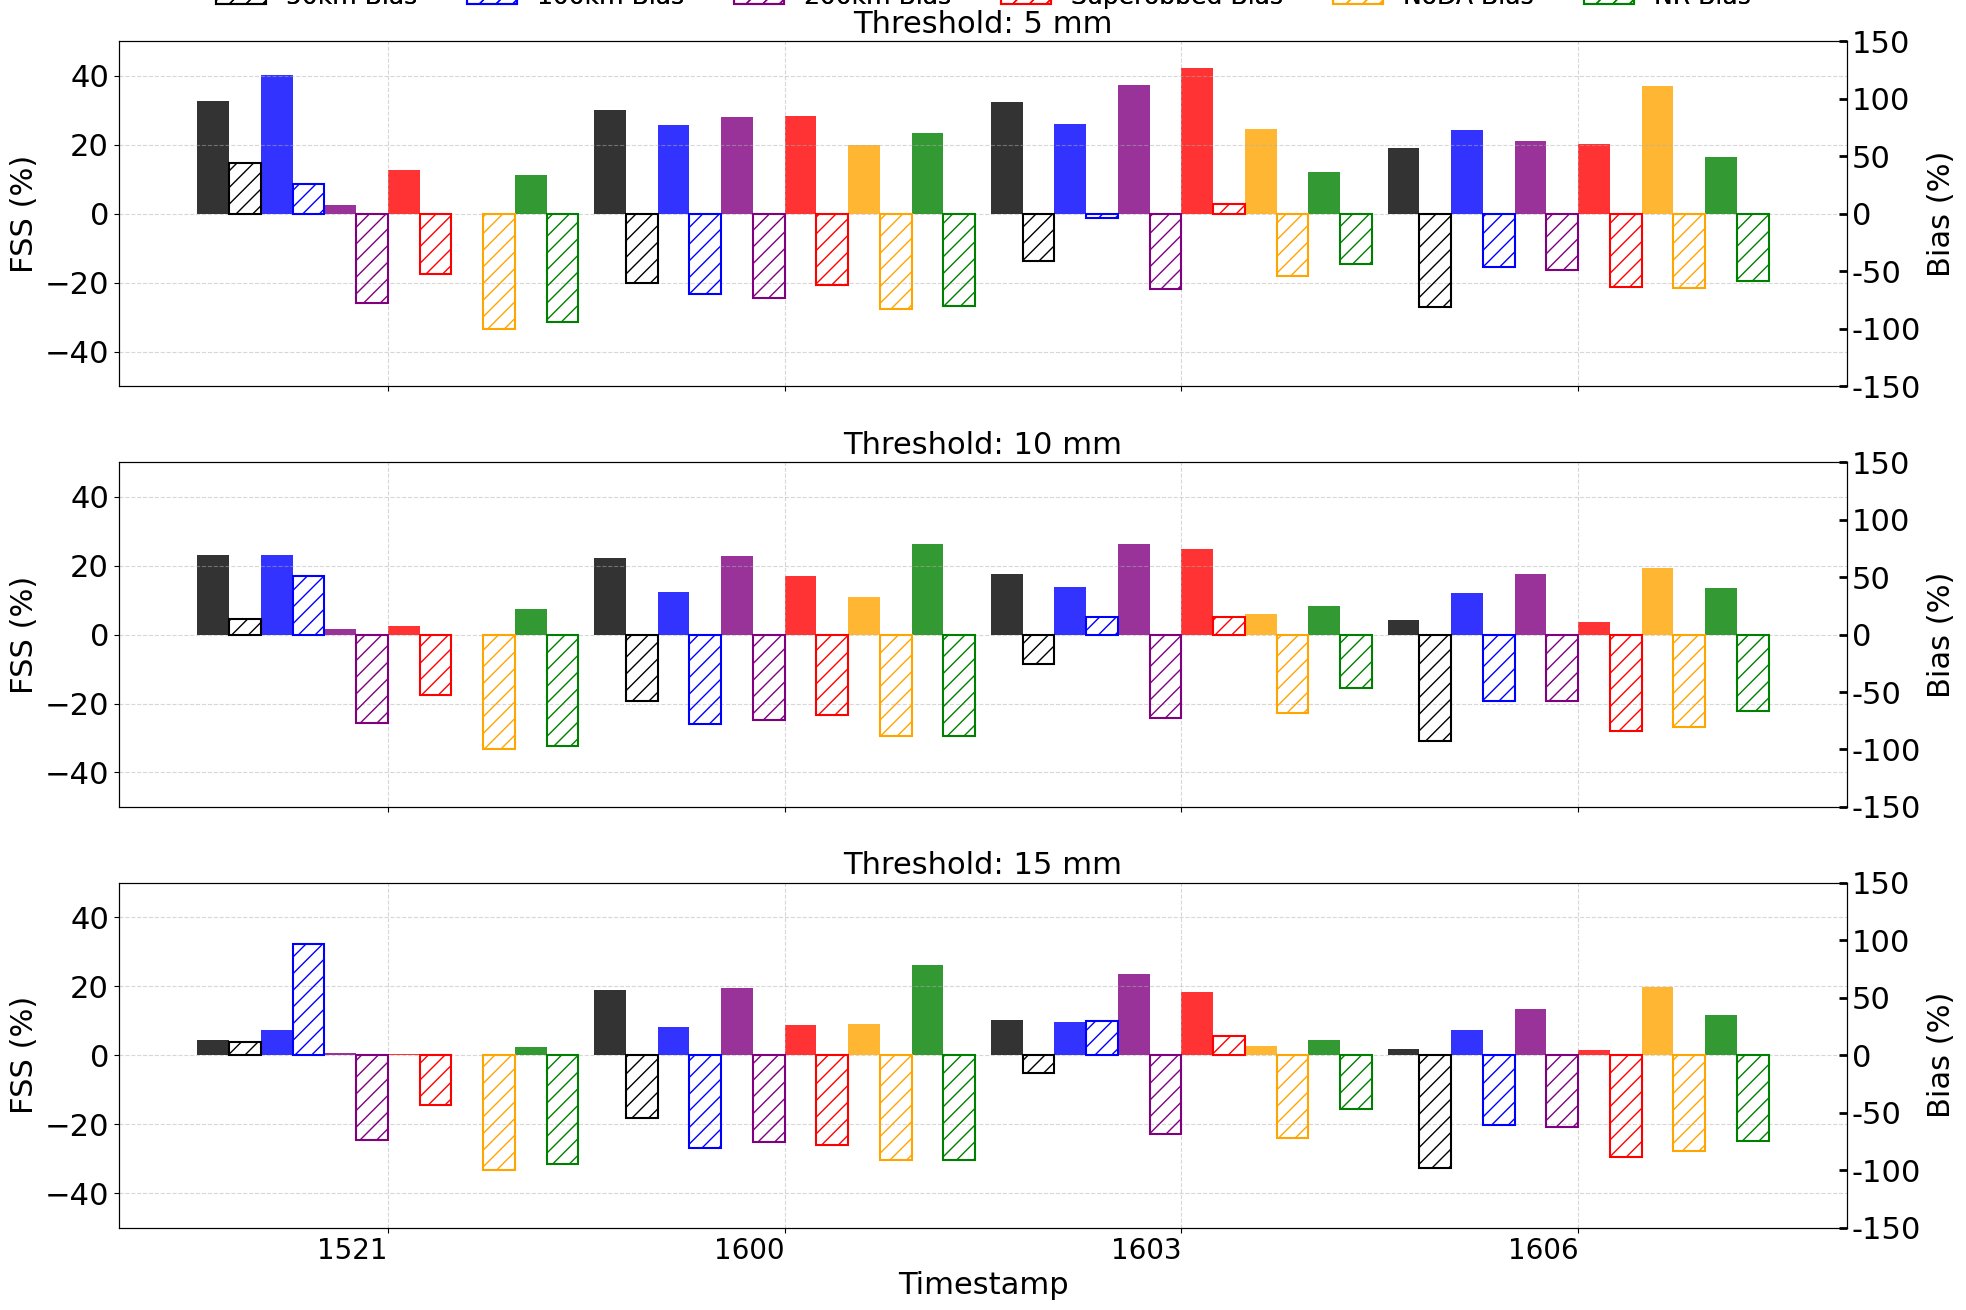

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

class FSSBiasPlotter:
    def __init__(self, files, fss_columns, bias_columns, group_size=4, gap_size=3, bar_width=0.08):
        self.files = files
        self.labels = list(files.values())
        self.fss_columns = fss_columns
        self.bias_columns = bias_columns
        self.group_size = group_size
        self.gap_size = gap_size
        self.bar_width = bar_width
        self.colors = ['black', 'blue', 'purple', 'red', 'orange', 'green']
        self.data = {}
        self.original_timestamps = None
        self.timestamps_grouped = []
        self.x_positions = None

    def load_data(self):
        for file, label in self.files.items():
            df = pd.read_csv(file)
            if self.original_timestamps is None:
                self.original_timestamps = df['timestamp']
            self.data[label] = df.set_index('timestamp')

    def generate_grouped_timestamps(self):
        ts_grouped = []
        for i in range(0, len(self.original_timestamps), self.group_size):
            group = list(self.original_timestamps[i:i + self.group_size])
            ts_grouped.extend(group)
            if i + self.group_size < len(self.original_timestamps):
                ts_grouped.extend([''] * self.gap_size)
        while ts_grouped and ts_grouped[-1] == '':
            ts_grouped.pop()
        self.timestamps_grouped = ts_grouped
        self.x_positions = np.arange(len(self.timestamps_grouped))

    def align_zero_axes(self, ax, ax2):
        y0_ax = ax.transData.transform((0, 0))[1]
        y0_ax2 = ax2.transData.transform((0, 0))[1]
        inv = ax2.transData.inverted()
        desired_0 = inv.transform((0, y0_ax))[1]
        current_ylim = ax2.get_ylim()
        offset_val = desired_0
        ax2.set_ylim(current_ylim[0] - offset_val, current_ylim[1] - offset_val)

    def plot(self, save_path='FSS_Bias_100km.jpg'):
        self.load_data()
        self.generate_grouped_timestamps()

        total_bars = 2 * len(self.labels)
        offset = (total_bars - 1) / 2 * self.bar_width

        fig, axs = plt.subplots(nrows=len(self.fss_columns), ncols=1,
                                figsize=(20, 14), sharex=True)

        for idx, (fss_col, bias_col) in enumerate(zip(self.fss_columns, self.bias_columns)):
            ax = axs[idx]
            ax2 = ax.twinx()

            for i, method in enumerate(self.labels):
                df = self.data[method]
                fss_vals = df[fss_col].reindex(self.original_timestamps).fillna(0) * 100
                bias_vals = (df[bias_col].reindex(self.original_timestamps).fillna(0) - 1) * 100

                fss_grouped, bias_grouped = [], []
                for j in range(0, len(self.original_timestamps), self.group_size):
                    fss_grouped.extend(fss_vals.iloc[j:j + self.group_size])
                    bias_grouped.extend(bias_vals.iloc[j:j + self.group_size])
                    if j + self.group_size < len(self.original_timestamps):
                        fss_grouped.extend([np.nan] * self.gap_size)
                        bias_grouped.extend([np.nan] * self.gap_size)

                fss_pos = self.x_positions + (2 * i) * self.bar_width - offset
                bias_pos = self.x_positions + (2 * i + 1) * self.bar_width - offset

                ax.bar(fss_pos, fss_grouped, width=self.bar_width,
                       color=self.colors[i], alpha=0.8, label=method)

                ax2.bar(bias_pos, bias_grouped, width=self.bar_width,
                        facecolor='none', edgecolor=self.colors[i],
                        linewidth=1.5, hatch='//', label=f"{method} Bias")

            threshold = fss_col.split("thr")[1].split("_")[0]
            ax.set_title(f"Threshold: {threshold} mm", fontsize=22)
            ax.set_ylabel("FSS (%)", fontsize=22)
            ax2.set_ylabel("Bias (%)", fontsize=22)

            ax.set_ylim(-50, 50)
            ax2.set_ylim(-150, 150)
            self.align_zero_axes(ax, ax2)

            bias_ticks = np.arange(-150, 151, 50)
            ax2.set_yticks(bias_ticks)
            ax2.set_yticklabels([f'{int(val)}' for val in bias_ticks], fontsize=22)

            ax2.yaxis.set_tick_params(which='both', direction='in', length=6, width=2, colors='black')
            ax2.spines['right'].set_position(('outward', 0))
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.tick_params(axis='both', labelsize=22)
            ax2.tick_params(axis='y', labelsize=22)

            if idx == 0:
                fss_legend = ax.legend(handles=ax.get_legend_handles_labels()[0],
                                       labels=self.labels,
                                       loc='upper center',
                                       bbox_to_anchor=(0.5, 1.33),
                                       fontsize=18,
                                       ncol=len(self.labels),
                                       frameon=False)

                bias_handles = [plt.Rectangle((0, 0), 1, 1, facecolor='none', edgecolor=self.colors[i],
                                              linewidth=1.5, hatch='//') for i in range(len(self.labels))]
                bias_labels = [f"{label} Bias" for label in self.labels]
                bias_legend = ax.legend(handles=bias_handles,
                                        labels=bias_labels,
                                        loc='upper center',
                                        bbox_to_anchor=(0.5, 1.23),
                                        fontsize=18,
                                        ncol=len(self.labels),
                                        frameon=False)

                ax.add_artist(fss_legend)
                ax.add_artist(bias_legend)

        axs[-1].set_xticks(self.x_positions)
        axs[-1].set_xticklabels(self.timestamps_grouped, fontsize=20, ha='right')
        axs[-1].set_xlabel("Timestamp", fontsize=22)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.savefig(save_path, dpi=100)
        print(f"Plot saved as: {save_path}")

# === Usage ===
if __name__ == "__main__":
    files = {
        "fss_bias_results_50km_multi_100km.csv": "50km",
        "fss_bias_results_100km_multi_100km.csv": "100km",
        "fss_bias_results_200km_multi_100km.csv": "200km",
        "fss_bias_results_superobbed_multi_100km.csv": "Superobbed",
        "fss_bias_results_NODA_multi_100km.csv": "NoDA",
        "fss_bias_results_NR_multi_100km.csv": "NR"
    }

    fss_columns = ["FSS_thr5_ws67", "FSS_thr10_ws67", "FSS_thr15_ws67"]
    bias_columns = ["Bias_thr5_ws67", "Bias_thr10_ws67", "Bias_thr15_ws67"]

    plotter = FSSBiasPlotter(files, fss_columns, bias_columns)
    plotter.plot()

#### Moisture flux convergence (kg m-2 s-1) superimposed with 10-m wind barbs at 6 hours into forecast from the initialization calculated at 700 hPa level applying low pass gaussian filter 

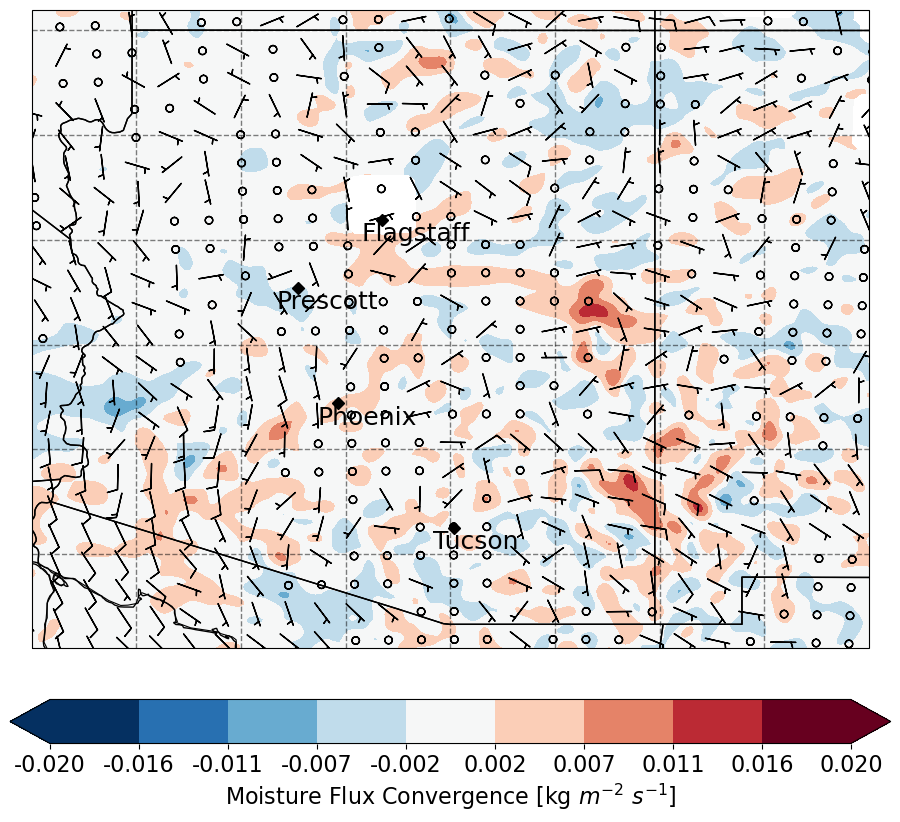

Saved plot to case01_100km_MFC_and_Wind_Barbs_700mb_2021-08-15_12:00:00.nc_LPF.jpg
All plots generated successfully!


In [80]:
import warnings
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mplt
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cf
from mpl_toolkits.axes_grid1 import make_axes_locatable
from netCDF4 import Dataset
from wrf import getvar, latlon_coords, interplevel, to_np
from scipy.ndimage import gaussian_filter

warnings.filterwarnings('ignore')

class MFCPlotter:
    def __init__(self, file_pattern='wrfout_d02_*', output_prefix='case01_100km'):
        self.file_pattern = file_pattern
        self.nc_files = sorted(glob.glob(file_pattern))
        self.output_prefix = output_prefix
        self.cities = {
            'Phoenix': (-112.07, 33.44),
            'Tucson': (-110.97, 32.25),
            'Prescott': (-112.46, 34.54),
            'Flagstaff': (-111.65, 35.19)
        }

    def run(self):
        if not self.nc_files:
            print("No NetCDF files matching the pattern were found.")
            return

        for file in self.nc_files:
            time_str = self.extract_time_str(file)
            with Dataset(file, 'r') as nc:
                flux_convergence_smooth, lat, lon, u10, v10, lats, lons = self.compute_fields(nc)
                self.plot_fields(flux_convergence_smooth, lat, lon, u10, v10, lats, lons, time_str)

        print("All plots generated successfully!")

    def extract_time_str(self, filepath):
        filename = filepath.split('/')[-1]
        time_str = filename.split('_')[2] + "_" + filename.split('_')[3].split('%')[0].replace('%3A', ':')
        return time_str

    def compute_fields(self, nc):
        # Get and interpolate variables
        qvapor = getvar(nc, "QVAPOR")
        ua = getvar(nc, "ua")
        va = getvar(nc, "va")
        pressure = getvar(nc, "P") + getvar(nc, "PB")
        target_pressure = 70000.0  # 700 mb

        qv_700 = interplevel(qvapor, pressure, target_pressure)
        ua_700 = interplevel(ua, pressure, target_pressure)
        va_700 = interplevel(va, pressure, target_pressure)
        lat, lon = latlon_coords(qv_700)

        # Moisture flux convergence
        q_flux_u = qv_700 * ua_700
        q_flux_v = qv_700 * va_700
        dqdx = np.gradient(to_np(q_flux_u), axis=1)
        dqdy = np.gradient(to_np(q_flux_v), axis=0)
        flux_convergence = -(dqdx + dqdy)
        flux_convergence_smooth = gaussian_filter(flux_convergence, sigma=2)

        # Near-surface winds
        u10 = to_np(getvar(nc, "U10"))
        v10 = to_np(getvar(nc, "V10"))
        lats, lons = map(to_np, latlon_coords(getvar(nc, "U10")))

        return flux_convergence_smooth, to_np(lat), to_np(lon), u10, v10, lats, lons

    def plot_fields(self, flux_convergence, lat, lon, u10, v10, lats, lons, time_str):
        fig = plt.figure(figsize=(12, 8))
        ax = plt.subplot(111, projection=ccrs.PlateCarree())
        plt.tight_layout()
        plt.rcParams.update({'font.size': 22})
        mplt.rc('xtick', labelsize=12)
        mplt.rc('ytick', labelsize=12)

        ax.set_extent([-115, -107, 31.1, 37.2])
        ax.add_feature(cf.BORDERS, linewidth=0.5, edgecolor='k')
        ax.coastlines('50m', linewidth=0.8)
        ax.add_feature(cf.STATES, edgecolor='k')
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                          linewidth=1, color='black', alpha=0.5, linestyle='--')
        gl.bottom_labels = gl.left_labels = False

        for city, (lon_c, lat_c) in self.cities.items():
            ax.plot(lon_c, lat_c, 'kD', transform=ccrs.PlateCarree())
            ax.text(lon_c - 0.2, lat_c - 0.2, city, transform=ccrs.PlateCarree(), fontsize=18)

        cmap = plt.cm.RdBu_r
        levels = np.linspace(-0.02, 0.02, 10)
        norm = matplotlib.colors.BoundaryNorm(levels, cmap.N)

        pc = ax.contourf(lon, lat, flux_convergence, levels=levels, cmap=cmap, norm=norm, extend='both')

        divider = make_axes_locatable(ax)
        cbar = fig.colorbar(pc, ax=ax, extend='both', orientation='horizontal', fraction=0.06, pad=0.07)
        cbar.set_label('Moisture Flux Convergence [kg $m^{-2}$ $s^{-1}$]', fontsize=16)
        cbar.ax.tick_params(labelsize=16)
        cbar.set_ticks(levels)
        cbar.ax.set_xticklabels([f"{lvl:.3f}" for lvl in levels])

        step = 10
        ax.barbs(lons[::step, ::step], lats[::step, ::step],
                 u10[::step, ::step], v10[::step, ::step],
                 length=6, pivot='middle', linewidth=1,
                 transform=ccrs.PlateCarree())

        output_file = f"{self.output_prefix}_MFC_and_Wind_Barbs_700mb_{time_str}_LPF.jpg"
        plt.savefig(output_file, dpi=360, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f"Saved plot to {output_file}")

# === Usage ===
if __name__ == "__main__":
    plotter = MFCPlotter(file_pattern='wrfout_d02_*', output_prefix='case01_100km')
    plotter.run()

#### Impact of Elevation on Moisture Forecasts

The boxplot shows the temporal averaged PWV bias of 12 hour forecasts compared against real PWV from 2021 campaign for both OSSE cases aggregated by GPS-met site elevation bins: 0-500m (4 stations), 500-1000m (4 stations), 1000-1500m (6 stations), 1500-2000m (8 stations) and 2000+ m (5 stations). OSSE experiments: Superobbed, 50-km, 100-km and 200-km arrays 


### Station Assignments by Altitude Band ###
0-500: AZBH, P003, P623, TNPP
500-1000: AZAM, GMPK, P001, SA46
1000-1500: KP52, LUCK, MORT, P010, P014, P026
1500-2000: ECHO, ERAU, KEND, MUND, P004, P008, P011, P015
2000+: AZRV, BIGE, KITT, MING, P107
Plot saved as: CASE01_all_experiment_bias_vs_altitude_ordered_final.jpg


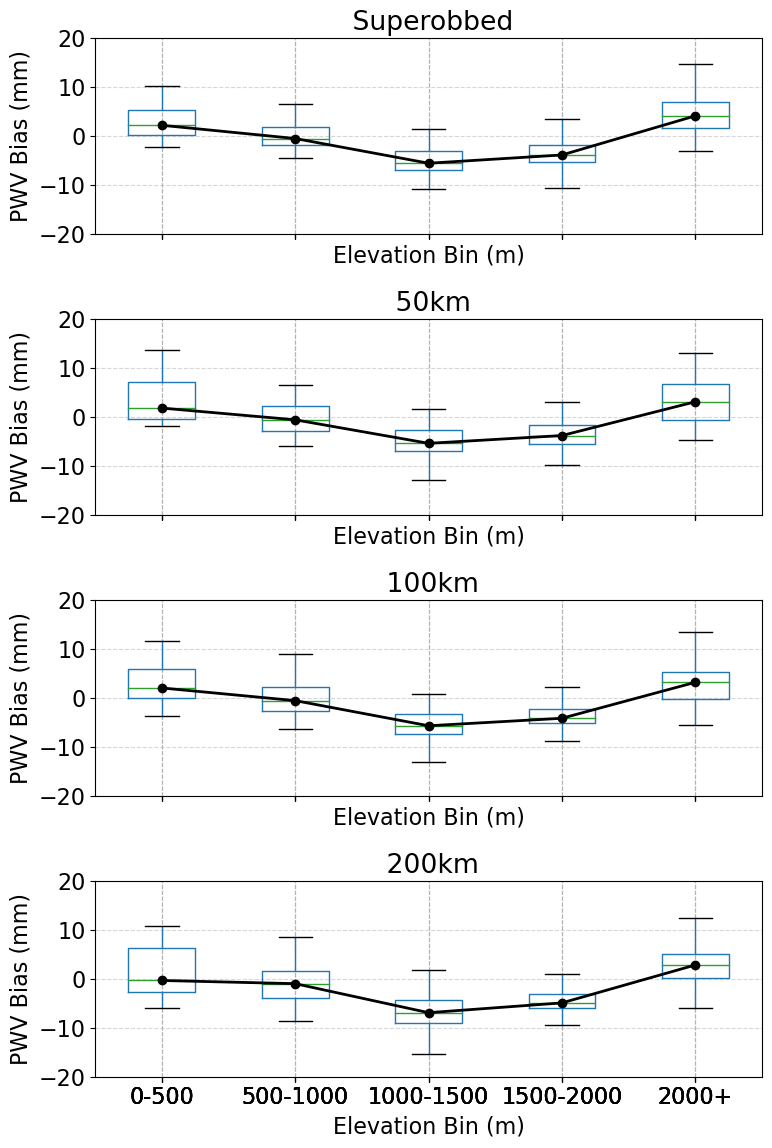

In [82]:
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt

class BiasAltitudePlotter:
    def __init__(self, file_pattern, station_altitudes, output_path):
        self.file_pattern = file_pattern
        self.station_altitudes = station_altitudes
        self.output_path = output_path
        self.bands = {
            "0-500": [], "500-1000": [], "1000-1500": [],
            "1500-2000": [], "2000+": []
        }
        self.data = pd.DataFrame()
        self.combined_data = None
        self.experiments = ["Superobbed", "50km", "100km", "200km"]
        self.colors = {
            'Superobbed': 'r', '50km': 'k', '100km': 'b', '200km': 'purple', 'NODA': 'orange'
        }

    def load_and_combine_data(self):
        files = sorted(glob.glob(self.file_pattern))
        for file in files:
            try:
                df = pd.read_csv(file, delim_whitespace=True, header=None,
                                 names=["StationID", "Timestamp", "Superobbed", "NODA",
                                        "50km", "100km", "200km", "NR", "REAL_OBS"])
                self.data = pd.concat([self.data, df], ignore_index=True)
            except Exception as e:
                print(f"Error reading {file}: {e}")

        self.data['Timestamp'] = pd.to_datetime(self.data['Timestamp'])
        self.combined_data = self.data.dropna()

    def categorize_stations_by_altitude(self):
        for station, altitude in self.station_altitudes.items():
            if 0 <= altitude < 500:
                self.bands["0-500"].append(station)
            elif 500 <= altitude < 1000:
                self.bands["500-1000"].append(station)
            elif 1000 <= altitude < 1500:
                self.bands["1000-1500"].append(station)
            elif 1500 <= altitude < 2000:
                self.bands["1500-2000"].append(station)
            else:
                self.bands["2000+"].append(station)

        print("\n### Station Assignments by Altitude Band ###")
        for band, stations in self.bands.items():
            print(f"{band}: {', '.join(stations) if stations else 'None'}")

    def plot_bias_by_altitude_band(self):
        fig, axes = plt.subplots(len(self.experiments), 1, figsize=(8, 12), sharex=True)
        axes = axes.flatten()
        plt.rcParams.update({'font.size': 16})

        for i, experiment in enumerate(self.experiments):
            bias_data = []

            for band, station_list in self.bands.items():
                subset = self.combined_data[self.combined_data['StationID'].isin(station_list)]
                if subset.empty:
                    continue
                biases = subset[experiment] - subset['REAL_OBS']
                for val in biases:
                    bias_data.append({'Altitude Band': band, 'Bias': val, 'Experiment': experiment})

            bias_df = pd.DataFrame(bias_data)
            bias_df["Altitude Band"] = pd.Categorical(bias_df["Altitude Band"],
                                                      categories=["0-500", "500-1000", "1000-1500",
                                                                  "1500-2000", "2000+"],
                                                      ordered=True)
            bias_df.sort_values("Altitude Band", inplace=True)

            ax = axes[i]
            bias_df.boxplot(column='Bias', by='Altitude Band', grid=False,
                            showfliers=False, ax=ax)

            median_values = bias_df.groupby('Altitude Band')['Bias'].median()
            median_values = median_values.reindex(["0-500", "500-1000", "1000-1500",
                                                   "1500-2000", "2000+"], fill_value=np.nan)

            ax.plot([1, 2, 3, 4, 5], median_values, marker='o', linestyle='-',
                    color='black', label=f"Median Bias ({experiment})", linewidth=2, zorder=3)

            ax.set_title(f" {experiment}")
            ax.set_xlabel("Elevation Bin (m)")
            ax.set_ylabel("PWV Bias (mm)")
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.set_ylim(-20, 20)
            ax.tick_params(axis='both', labelsize=16)

        plt.suptitle("")
        plt.tight_layout()
        plt.savefig(self.output_path, dpi=100, bbox_inches='tight')
        print(f"Plot saved as: {self.output_path}")
        plt.show()

    def run_all(self):
        self.load_and_combine_data()
        self.categorize_stations_by_altitude()
        self.plot_bias_by_altitude_band()

# === USAGE ===
if __name__ == "__main__":
    station_altitudes = {
        "AZAM": 958.24, "AZBH": 181.07, "AZRV": 2132.79, "BIGE": 2572.44, "ECHO": 1706.33,
        "ERAU": 1575.95, "GMPK": 624.46, "KEND": 1531.00, "KITT": 2090.19, "KP52": 1058.50,
        "LUCK": 1370.00, "MING": 2291.30, "MORT": 1363.23, "MUND": 1949.35, "P001": 506.30,
        "P003": 83.39, "P004": 1816.44, "P008": 1544.57, "P010": 1427.85, "P011": 1747.55,
        "P014": 1098.61, "P015": 1953.67, "P026": 1260.31, "P107": 2011.30, "P623": 298.90,
        "SA46": 761.58, "TNPP": 61.85
    }

    plotter = BiasAltitudePlotter(
        file_pattern="combined_Pseudo_Trans_SAM_hr_*.dat",
        station_altitudes=station_altitudes,
        output_path="CASE01_all_experiment_bias_vs_altitude_ordered_final.jpg"
    )
    plotter.run_all()